# Trabajo de Portafolio Semestral — Réplica y extensión de un paper de ML

**Curso:** Ciencia de Datos para la Economía
**Profesor:** Luis Cuevas Parra
**Año:** 2026

**Paper seleccionado (Bloque B — Riesgo financiero, crédito y clientes, #6):**

> Moscato, V., Picariello, A., & Sperlí, G. (2021). *A benchmark of machine learning approaches for credit score prediction.* Expert Systems with Applications, 165, 113986. https://doi.org/10.1016/j.eswa.2020.113986

- **Revista / cuartil:** Expert Systems with Applications — Q1 (Artificial Intelligence / Computer Science Applications, SCImago 2024)
- **Modelo(s) de ML del paper:** Regresión logística, árboles de decisión, random forest, redes neuronales y métodos de ensamble, con técnicas de balanceo de clases (submuestreo/sobremuestreo).
- **Datos:** Préstamos P2P de LendingClub, originados en 2016-2017 (877.956 registros, 151 variables en el paper original), disponibles en Kaggle ("All Lending Club loan data").

**Integrantes del grupo:**
- Carla Aguilera
- Joaquín Flores
- Sebastián Gutiérrez
- Benjamín Romero

Ver `README.md` del repositorio para la guía de exposición oral y las instrucciones de ejecución.

---


## 1. Resumen del paper

**Pregunta de investigación:** ¿Qué tan bien predicen distintos algoritmos de Machine Learning
el riesgo crediticio (credit scoring) de solicitantes de préstamos P2P bajo distintas técnicas de
balanceo de clases, y cuál combinación modelo+técnica de muestreo ofrece el mejor desempeño
como benchmark?

**Datos utilizados por los autores:** Préstamos de la plataforma LendingClub (EE.UU.),
**originados específicamente en 2016 y 2017**, compuestos por 877.956 registros y 151
variables (datos del solicitante, características del préstamo, estado de pago, etc.). La
variable objetivo es binaria: préstamo pagado (`Fully Paid`) vs. en default (`Charged Off`
y estados equivalentes).

**Metodología (resumen):** Los autores preprocesan los datos (limpieza, imputación,
codificación de variables categóricas) y entrenan varios modelos supervisados de
clasificación —regresión logística, árboles de decisión, random forest y redes neuronales—
combinados con **distintas técnicas de muestreo** para tratar el desbalance de clases:
técnicas de sobremuestreo y, sobre todo, de **submuestreo** (Random Under-Sampling, RUS)
e Instance Hardness Threshold (IHT). Evalúan el desempeño con AUC, Sensitivity (recall) y
Specificity, y adicionalmente analizan la explicabilidad de los tres mejores modelos con
LIME y SHAP.

**Principales resultados del paper:**
- La combinación **Random Forest + Random Under-Sampling (RF-RUS)** obtuvo el mejor
  desempeño global: **AUC ≈ 71,7%**, **accuracy ≈ 64%**, **recall/sensitivity ≈ 63%**.
- En general, los métodos de ensamble (random forest) superaron a la regresión logística,
  aunque la diferencia no es enorme cuando las variables están bien seleccionadas.
- Las técnicas de **submuestreo (RUS/IHT)** dieron mejores resultados que las de
  sobremuestreo para este problema y este dataset en particular.
- El análisis de explicabilidad (LIME/SHAP) identificó variables como la tasa de interés
  (`int_rate`), el grado de riesgo (`grade`) y el ratio deuda/ingreso (`dti`) como las más
  influyentes en la predicción de default — variables que también usamos en este trabajo.

**Nota sobre alcance de la réplica:** el benchmark completo de explicabilidad del paper
(LIME, SHAP, Anchors, BEEF, LORE comparados por *trust*, Tabla 10) queda fuera del alcance
de este portafolio -- nos concentramos en replicar el desempeño predictivo (AUC,
Sensitivity, Specificity) de los modelos.

---


## 2. Datos

### 2.1 Fuente de datos

El dataset **"All Lending Club loan data"** está disponible públicamente en Kaggle:

https://www.kaggle.com/datasets/wordsforthewise/lending-club

Contiene información de préstamos P2P originados en la plataforma LendingClub entre
aproximadamente 2007 y 2018, con más de 2 millones de registros y más de 140 variables.
Para acercarnos al diseño experimental de Moscato et al. (2021), en la Sección 2.9
filtramos este dataset a los préstamos **originados en 2016-2017**, tal como hacen los
autores.

### 2.2 Requisitos previos para la descarga

Desde abril de 2024, Kaggle permite descargar **datasets públicos** vía API **sin necesitar
una cuenta ni token**. Por lo tanto, para este dataset en particular es probable que la
descarga funcione directamente (ver sección 2.5).

Aun así, conviene tener credenciales listas como respaldo, ya que algunos datasets exigen
aceptar reglas/términos explícitos antes de permitir la descarga (en ese caso sí es obligatorio
autenticarse):

1. Una cuenta en [kaggle.com](https://www.kaggle.com).
2. Un token de API: en tu perfil de Kaggle → *Settings* → *API* → *Create New Token*. Esto
   descarga un archivo `kaggle.json`.
3. Colocar `kaggle.json` en `~/.kaggle/kaggle.json` (Linux/Mac) o `C:\\Users\\<usuario>\\.kaggle\\kaggle.json` (Windows), o exportar las variables de entorno `KAGGLE_USERNAME` y `KAGGLE_KEY`.
4. Si el dataset lo exige, aceptar sus reglas/términos en la página web de Kaggle antes de
   intentar la descarga vía API.

### 2.3 Instalación de librerías necesarias


In [ ]:
# Ejecutar solo la primera vez / si falta alguna librería
%pip install -q kaggle pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost


### 2.4 Importación de librerías

In [ ]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


### 2.5 Descarga del dataset desde Kaggle

Desde abril de 2024, Kaggle permite descargar **datasets públicos** a través de su API
**sin necesidad de autenticación** (`kaggle.json`). La excepción son datasets que exigen
aceptar reglas/términos explícitos antes de la descarga, en cuyo caso sí se requiere una
cuenta autenticada (ver sección 2.2).

La celda de abajo primero intenta la descarga **sin autenticar**; si Kaggle exige login para
este dataset en particular, cae automáticamente al flujo autenticado con `kaggle.json`.


In [ ]:
# Opción A: descarga vía Kaggle API (intenta primero sin autenticación,
# y si el dataset lo exige, cae a autenticación con kaggle.json)

# Nota: puede requerir ejecutarse dos veces (la primera tira error) en algunos entornos
KAGGLE_DATASET = "wordsforthewise/lending-club"

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()

def descargar_dataset(autenticar):
    if autenticar:
        api.authenticate()
    print("Descargando dataset '" + KAGGLE_DATASET + "' (autenticado=" + str(autenticar) + ") ...")
    api.dataset_download_files(KAGGLE_DATASET, path=str(DATA_DIR), unzip=True, quiet=False)
    print("Descarga completa. Archivos disponibles en:", DATA_DIR.resolve())

try:
    descargar_dataset(autenticar=False)
except Exception as e_sin_auth:
    print("La descarga sin autenticación falló (puede que este dataset exija login).")
    print("Detalle:", e_sin_auth)
    print("Intentando con autenticación (requiere kaggle.json, ver seccion 2.2)...")
    try:
        descargar_dataset(autenticar=True)
    except Exception as e_con_auth:
        print("Tampoco se pudo autenticar/descargar con kaggle.json.")
        print("Revisa que el archivo este en ~/.kaggle/kaggle.json y sea valido.")
        print("Detalle:", e_con_auth)


Opción B: descarga manual.

Si la Opción A falla (por ejemplo, por restricciones de red del entorno de ejecución), se puede:

1. Descargar manualmente el .zip desde
   https://www.kaggle.com/datasets/wordsforthewise/lending-club
2. Colocarlo en la carpeta `data/` de este proyecto.
3. Ejecutar la celda siguiente para descomprimirlo.


In [ ]:
# Opción B: descompresión manual de un .zip ya descargado en data/
# En caso de que el anterior falle, dejar una alternativa.
zip_candidates = list(DATA_DIR.glob("*.zip"))

if zip_candidates:
    zip_path = zip_candidates[0]
    print(f"Descomprimiendo {zip_path.name} ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_DIR)
    print("Listo.")
else:
    print("No se encontraron archivos .zip en data/. "
          "Si ya ejecutaste la Opción A con éxito, puedes ignorar este mensaje.")


### 2.6 Archivos disponibles tras la descarga

In [ ]:
for f in sorted(DATA_DIR.rglob("*")):
    if f.is_file():
        size_mb = f.stat().st_size / (1024 ** 2)
        rel_path = str(f.relative_to(DATA_DIR))
        print(f"{rel_path:60s}  {size_mb:8.2f} MB")


accepted_2007_to_2018Q4.csv.gz                                  374.40 MB
accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv        1597.53 MB
rejected_2007_to_2018Q4.csv.gz                                  243.64 MB
rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv        1699.72 MB


### 2.7 Carga del dataset principal

El dataset completo es muy grande (millones de filas, >100 columnas), por lo que se recomienda:

- Cargar primero una muestra (`nrows=...`) o solo un subconjunto de columnas para explorar la
  estructura antes de trabajar con el archivo completo.
- Definir en una lista `COLUMNS_TO_USE` las variables relevantes (análogas a las usadas por
  Moscato et al., 2021), para no cargar en memoria las ~150 columnas del archivo original.
- **Importante:** se agrega la columna `issue_d` (fecha de originación del préstamo), necesaria
  para el filtro temporal 2016-2017 de la Sección 2.9.

Ajustar `MAIN_FILE` al nombre real del archivo CSV descargado (por ejemplo `accepted_2007_to_2018Q4.csv.gz` u otro, según la versión del dataset).


In [ ]:
# Ajustar según el/los archivo(s) efectivamente descargados en data/
csv_candidates = [
    f for f in list(DATA_DIR.rglob("*.csv")) + list(DATA_DIR.rglob("*.csv.gz"))
    if f.is_file()  # descarta directorios que compartan el mismo nombre
]
print("Archivos CSV encontrados:")
for f in csv_candidates:
    print(" -", f)

# Preferimos el archivo de préstamos ACEPTADOS (tiene loan_status, grade, etc.)
# por sobre el de rechazados (rejected), que no trae esas columnas.
accepted_files = [f for f in csv_candidates if "accepted" in f.name.lower()]

if accepted_files:
    MAIN_FILE = accepted_files[0]
elif csv_candidates:
    MAIN_FILE = csv_candidates[0]
else:
    MAIN_FILE = None

print("\nMAIN_FILE seleccionado:", MAIN_FILE)


Archivos CSV encontrados:
 - data/rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv
 - data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
 - data/rejected_2007_to_2018Q4.csv.gz
 - data/accepted_2007_to_2018Q4.csv.gz

MAIN_FILE seleccionado: data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv


**Resumen breve:**

Se amplió el conjunto de variables utilizadas porque la validación cruzada mostró un AUC sistemáticamente inferior al del paper, con muy baja variabilidad, lo que sugiere un **sesgo por variables omitidas** y no un problema de muestreo. Por ello, se decidió incluir la mayor cantidad posible de **variables disponibles al momento de originación del préstamo**, tal como exige la metodología original.

Se excluyeron explícitamente todas las variables que implican **fuga de información** (resultados de pago, recuperaciones, programas de hardship o settlement, FICO actualizado), además de identificadores, texto libre, variables de alta cardinalidad o redundantes (como `funded_amnt` y `funded_amnt_inv`), y otras con escasa utilidad o ambigüedad temporal.


In [ ]:
COLUMNS_TO_USE = [
    # --- Términos del préstamo (conocidos al originar) ---
    "loan_amnt", "term", "int_rate", "installment", "grade", "sub_grade",
    "initial_list_status", "application_type", "disbursement_method",

    # --- Perfil del solicitante ---
    "emp_length", "home_ownership", "annual_inc", "verification_status",
    "purpose", "addr_state", "dti",

    # --- Historial crediticio (buró) al momento de la solicitud ---
    "delinq_2yrs", "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc",
    "fico_range_low", "fico_range_high", "inq_last_6mths",
    "mths_since_last_delinq", "mths_since_last_record", "mths_since_last_major_derog",
    "collections_12_mths_ex_med", "acc_now_delinq", "tot_coll_amt", "tot_cur_bal",
    "open_acc_6m", "open_act_il", "open_il_12m", "open_il_24m", "mths_since_rcnt_il",
    "total_bal_il", "il_util", "open_rv_12m", "open_rv_24m", "max_bal_bc", "all_util",
    "total_rev_hi_lim", "inq_fi", "total_cu_tl", "inq_last_12m",
    "acc_open_past_24mths", "avg_cur_bal", "bc_open_to_buy", "bc_util",
    "chargeoff_within_12_mths", "delinq_amnt", "mo_sin_old_il_acct",
    "mo_sin_old_rev_tl_op", "mo_sin_rcnt_rev_tl_op", "mo_sin_rcnt_tl", "mort_acc",
    "mths_since_recent_bc", "mths_since_recent_bc_dlq", "mths_since_recent_inq",
    "mths_since_recent_revol_delinq", "num_accts_ever_120_pd", "num_actv_bc_tl",
    "num_actv_rev_tl", "num_bc_sats", "num_bc_tl", "num_il_tl", "num_op_rev_tl",
    "num_rev_accts", "num_rev_tl_bal_gt_0", "num_sats", "num_tl_120dpd_2m",
    "num_tl_30dpd", "num_tl_90g_dpd_24m", "num_tl_op_past_12m", "pct_tl_nvr_dlq",
    "percent_bc_gt_75", "pub_rec_bankruptcies", "tax_liens", "tot_hi_cred_lim",
    "total_bal_ex_mort", "total_bc_limit", "total_il_high_credit_limit",
    "earliest_cr_line",  # fecha -> se transforma en "credit_history_months" (Sección 3.2)

    # --- Solicitud conjunta (co-solicitante), casi siempre NaN si es individual ---
    "annual_inc_joint", "dti_joint", "verification_status_joint", "revol_bal_joint",
    "sec_app_fico_range_low", "sec_app_fico_range_high", "sec_app_inq_last_6mths",
    "sec_app_mort_acc", "sec_app_open_acc", "sec_app_revol_util",
    "sec_app_open_act_il", "sec_app_num_rev_accts",
    "sec_app_chargeoff_within_12_mths", "sec_app_collections_12_mths_ex_med",
    "sec_app_mths_since_last_major_derog",

    # --- Variable objetivo y fecha de originación (para filtrar por año) ---
    "loan_status", "issue_d",
]

if MAIN_FILE is not None:
    # Primero una muestra pequeña para validar que las columnas existen
    df_sample = pd.read_csv(MAIN_FILE, nrows=5)
    cols_present = [c for c in COLUMNS_TO_USE if c in df_sample.columns]
    cols_missing = [c for c in COLUMNS_TO_USE if c not in df_sample.columns]
    print(f"Columnas encontradas ({len(cols_present)} de {len(COLUMNS_TO_USE)}):")
    print(cols_present)
    print(f"\nColumnas NO encontradas (revisar nombres / versión del dataset) "
          f"({len(cols_missing)}):")
    print(cols_missing)
    print("\nNota: si faltan columnas es normal — distintas descargas/versiones del CSV de")
    print("Kaggle han tenido pequeñas variaciones de nombres/columnas a través de los años.")
    print("El código de más abajo usa siempre 'cols_present' (o el equivalente filtrado por")
    print("'in df_model.columns'), así que nunca falla por una columna ausente.")
else:
    print("MAIN_FILE es None: aún no hay un CSV descargado en data/. "
          "Completa la sección 2.5/2.6 antes de continuar.")


Columnas encontradas (102 de 102):
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'initial_list_status', 'application_type', 'disbursement_method', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_

In [ ]:
# Carga completa (o por chunks si el archivo es muy grande) usando solo las columnas de interés
if MAIN_FILE is not None:
    df = pd.read_csv(
        MAIN_FILE,
        usecols=lambda c: c in COLUMNS_TO_USE,
        low_memory=False,
    )
    print("Shape del dataset (histórico completo, antes de filtrar por año):", df.shape)
    display(df.head())
else:
    df = None
    print("Pendiente: descargar el dataset (sección 2.5) antes de cargarlo aquí.")


Shape del dataset (histórico completo, antes de filtrar por año): (2260701, 102)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,...,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,disbursement_method
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,debt_consolidation,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.0,30.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,...,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,small_business,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.0,NaN,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,...,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,home_improvement,IL,10.78,0.0,Aug-2000,695.0,699.0,0.0,NaN,NaN,6.0,0.0,7869.0,56.2,18.0,w,0.0,NaN,Joint App,71000.0,13.85,Not Verified,0.0,0.0,189699.0,0.0,1.0,0.0,4.0,19.0,10827.0,73.0,0.0,2.0,2081.0,65.0,14000.0,2.0,...,6.0,31617.0,2737.0,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,101.0,NaN,10.0,NaN,0.0,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
3,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,debt_consolidation,NJ,17.06,0.0,Sep-2008,785.0,789.0,0.0,NaN,NaN,13.0,0.0,7802.0,11.6,17.0,w,0.0,NaN,Individual,NaN,NaN,NaN,0.0,0.0,301500.0,1.0,1.0,0.0,1.0,23.0,12609.0,70.0,1.0,1.0,6987.0,45.0,67300.0,0.0,...,2.0,23192.0,54962.0,12.1,0.0,0.0,36.0,87.0,2.0,2.0,1.0,2.0,NaN,NaN,NaN,0.0,4.0,5.0,8.0,10.0,2.0,10.0,13.0,5.0,13.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,major_purchase,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,NaN,12.0,0.0,21929.0,64.5,35.0,w,0.0,NaN,Individual,NaN,NaN,

### 2.8 Exploración inicial (EDA preliminar)

In [ ]:
if df is not None:
    print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 102 entries, loan_amnt to disbursement_method
dtypes: float64(87), str(15)
memory usage: 1.7 GB
None


In [ ]:
if df is not None:
    print("Valores faltantes por columna (%):")
    display((df.isna().mean() * 100).sort_values(ascending=False).round(2))

Valores faltantes por columna (%):


sec_app_mths_since_last_major_derog    98.41
sec_app_revol_util                     95.30
revol_bal_joint                        95.22
sec_app_mort_acc                       95.22
sec_app_fico_range_high                95.22
                                       ...  
fico_range_low                          0.00
fico_range_high                         0.00
revol_bal                               0.00
initial_list_status                     0.00
disbursement_method                     0.00
Length: 102, dtype: float64

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64

/var/folders/y1/sws8hp854tx58q1yy9m9vmyr0000gn/T/ipykernel_91564/2198895906.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


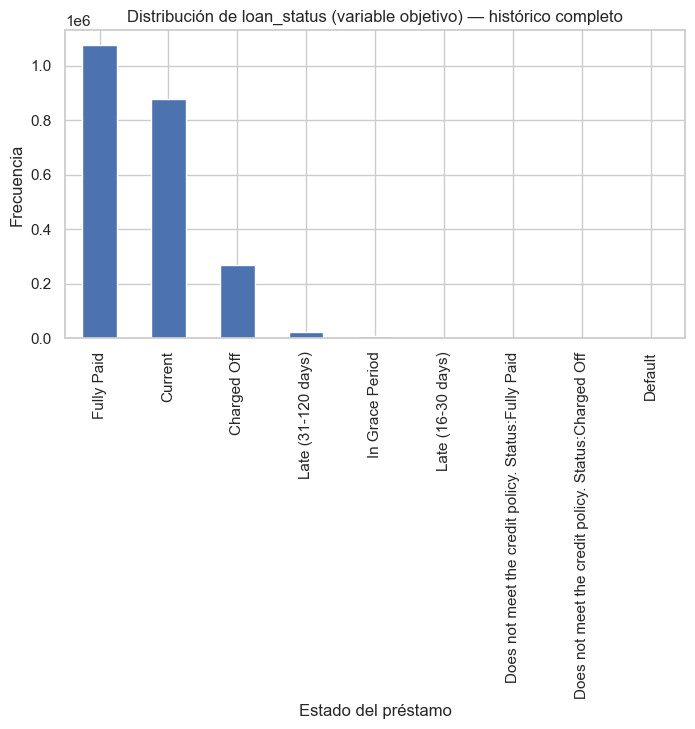

In [ ]:
if df is not None and "loan_status" in df.columns:
    display(df["loan_status"].value_counts(dropna=False))

    plt.figure(figsize=(8, 4))
    df["loan_status"].value_counts().plot(kind="bar")
    plt.title("Distribución de loan_status (variable objetivo) — histórico completo")
    plt.xlabel("Estado del préstamo")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

In [ ]:
if df is not None:
    display(df.describe(include="number").T)

,count,mean,std,min,25%,50%,75%,max
loan_amnt,2260668.0,15046.931228,9190.245488,500.00,8000.00,12900.00,20000.00,4.000000e+04
int_rate,2260668.0,13.092829,4.832138,5.31,9.49,12.62,15.99,3.099000e+01
installment,2260668.0,445.806823,267.173535,4.93,251.65,377.99,593.32,1.719830e+03
annual_inc,2260664.0,77992.428687,112696.199574,0.00,46000.00,65000.00,93000.00,1.100000e+08
dti,2258957.0,18.824196,14.183329,-1.00,11.89,17.84,24.49,9.990000e+02
...,...,...,...,...,...,...,...,...
sec_app_open_act_il,108021.0,3.010554,3.275893,0.00,1.00,2.00,4.00,4.300000e+01
sec_app_num_rev_accts,108021.0,12.533072,8.150964,0.00,7.00,11.00,17.00,1.060000e+02
sec_app_chargeoff_within_12_mths,108021.0,0.046352,0.411496,0.00,0.00,0.00,0.00,2.100000e+01
sec_app_collections_12_mths_ex_med,108021.0,0.077568,0.407996,0.00,0.00,0.00,0.00,2.300000e+01


### 2.9 Filtro temporal: préstamos originados en 2016-2017

Moscato et al. (2021) **no usan todo el histórico** de LendingClub (2007-2018): se enfocan
específicamente en préstamos originados en **2016 y 2017**, lo que en su caso arroja
877.956 registros con 151 variables. Replicamos ese mismo filtro temporal aquí, usando la
columna `issue_d` (fecha de originación del préstamo).

**Razón metodológica (para la discusión de la Sección 7):** los préstamos a 36-60 meses
necesitan tiempo para llegar a un estado terminal (pagado o default). Años muy recientes
dejarían demasiados préstamos aún "Current"; años muy antiguos corresponden a una
plataforma con menor volumen y criterios de originación distintos. 2016-2017 es un punto
intermedio: alto volumen y tiempo suficiente para tener desenlaces definitivos al momento
de la publicación del paper (2020-2021).


In [ ]:
if df is not None and "issue_d" in df.columns:
    df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
    n_antes = df.shape[0]
    df = df[df["issue_d"].dt.year.isin([2016, 2017])].copy()
    n_despues = df.shape[0]

    print(f"Registros antes del filtro temporal: {n_antes:,}")
    print(f"Registros tras filtrar a 2016-2017  : {n_despues:,}")
    print(f"Referencia del paper (Moscato et al., 2021): 877,956 registros")
else:
    print("df o 'issue_d' no disponibles todavía.")

Registros antes del filtro temporal: 2,260,701
Registros tras filtrar a 2016-2017  : 877,986
Referencia del paper (Moscato et al., 2021): 877,956 registros


**Nota sobre alcance:** el paper trabaja con 151 variables. Ampliamos `COLUMNS_TO_USE`
(Sección 2.7) a la mayor cantidad de variables
"seguras" (conocidas al momento de originación, sin fuga de información) que pudimos
identificar en el diccionario de datos de LendingClub — quedando cerca de las ~151 del
paper, aunque no exactamente iguales, porque los autores no publican la lista completa
de columnas que usaron (detalle de qué se excluyó y por qué, en los comentarios de la
Sección 2.7).

---


## 3. Preprocesamiento e ingeniería de atributos

En esta sección construimos la variable objetivo binaria, limpiamos tipos de datos,
tratamos los valores faltantes (imputación) y dejamos los datos listos para entrenar
los modelos de la Sección 4.

Orden seguido:

1. Definir la variable objetivo y quedarnos solo con préstamos en estado "terminal"
   (pagados o en default), tal como hacen Moscato et al. (2021).
2. Corregir tipos de columnas que vienen como texto pero son numéricas (`term`,
   `emp_length`, `int_rate`, `revol_util`).
3. Analizar el patrón de valores faltantes.
4. Imputar: mediana para variables numéricas, moda (o categoría "Desconocido") para
   categóricas — usando `SimpleImputer` de scikit-learn dentro de un `Pipeline`, para
   evitar *data leakage* (la imputación se ajusta solo con datos de entrenamiento).
5. Codificar variables categóricas (One-Hot) y escalar las numéricas.
6. Separar en train/test de forma estratificada y balancear las clases del set de
   entrenamiento con **Random Under-Sampling (RUS)** — la técnica que da el mejor
   resultado en el paper (combinación RF-RUS), y además mucho más liviana
   computacionalmente que SMOTE.

### 3.1 Definición de la variable objetivo (`default`)


Se conservaron únicamente los préstamos con un **resultado definitivo** (totalmente pagados o en *default/charged off*), excluyendo aquellos que seguían activos o en estados transitorios (como *Current* o períodos de gracia), ya que aún no presentan un desenlace final, siguiendo el criterio de Moscato et al. (2021).


In [ ]:
if df is not None and "loan_status" in df.columns:
    print("Valores originales de loan_status:")
    display(df["loan_status"].value_counts(dropna=False))

    ESTADOS_PAGADO = ["Fully Paid"]
    ESTADOS_DEFAULT = ["Charged Off", "Default",
                       "Does not meet the credit policy. Status:Charged Off"]
    ESTADOS_PAGADO += ["Does not meet the credit policy. Status:Fully Paid"]

    df_model = df[df["loan_status"].isin(ESTADOS_PAGADO + ESTADOS_DEFAULT)].copy()

    df_model["default"] = df_model["loan_status"].isin(ESTADOS_DEFAULT).astype(int)

    print("\nRegistros tras quedarnos solo con estados terminales:", df_model.shape)
    print("\nDistribución de la variable objetivo (default = 1):")
    display(df_model["default"].value_counts(normalize=True).round(4) * 100)
else:
    df_model = None
    print("df aún no está cargado (ver Sección 2). Esta celda se activará una vez "
          "descargado y filtrado el dataset.")


Valores originales de loan_status:


loan_status
Current               395912
Fully Paid            355005
Charged Off           107390
Late (31-120 days)     12550
In Grace Period         4704
Late (16-30 days)       2394
Default                   31
Name: count, dtype: int64


Registros tras quedarnos solo con estados terminales: (462426, 103)

Distribución de la variable objetivo (default = 1):


default
0    76.77
1    23.23
Name: proportion, dtype: float64

### 3.2 Limpieza de tipos de datos

La variable `emp_length` se transformó desde categorías de texto (por ejemplo, "< 1 year" o "10+ years") a una **escala numérica ordinal de 0 a 10**, preservando el orden de la experiencia laboral. Asimismo, las variables expresadas como porcentajes (como `int_rate`, `revol_util` y otros indicadores de buró) se convirtieron de texto a formato numérico cuando fue necesario, utilizando `is_numeric_dtype` para garantizar compatibilidad con distintas versiones de pandas y del conjunto de datos. Finalmente, la fecha de apertura de la primera línea de crédito (`earliest_cr_line`) se transformó en la variable **`credit_history_months`**, que mide la antigüedad del historial crediticio en meses al momento de originación del préstamo, un predictor ampliamente utilizado en modelos de *credit scoring*.


In [ ]:
if df_model is not None:
    # term viene como " 36 months" / " 60 months" -> lo dejamos como entero
    if "term" in df_model.columns:
        df_model["term"] = (
            df_model["term"].astype(str).str.extract(r"(\d+)").astype(float)
        )

    # emp_length viene como "< 1 year", "1 year", ..., "10+ years" -> lo mapeamos a un
    # entero (0 a 10), preservando el orden (variable numérica/ordinal)
    if "emp_length" in df_model.columns:
        mapa_emp_length = {
            "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
            "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
            "10+ years": 10,
        }
        df_model["emp_length"] = df_model["emp_length"].map(mapa_emp_length)

    cols_posible_pct = [
        "int_rate", "revol_util", "il_util", "all_util", "bc_util",
        "percent_bc_gt_75", "pct_tl_nvr_dlq",
    ]
    for col in cols_posible_pct:
        if col in df_model.columns and not pd.api.types.is_numeric_dtype(df_model[col]):
            df_model[col] = (
                df_model[col].astype(str).str.replace("%", "", regex=False).astype(float)
            )

    if "earliest_cr_line" in df_model.columns and "issue_d" in df_model.columns:
        earliest_dt = pd.to_datetime(df_model["earliest_cr_line"], format="%b-%Y", errors="coerce")
        # issue_d ya quedó como datetime tras el filtro temporal de la Sección 2.9
        df_model["credit_history_months"] = (
            (df_model["issue_d"].dt.year - earliest_dt.dt.year) * 12
            + (df_model["issue_d"].dt.month - earliest_dt.dt.month)
        )
        df_model = df_model.drop(columns=["earliest_cr_line"])
        print(f"\ncredit_history_months creada a partir de earliest_cr_line "
              f"(NaN: {df_model['credit_history_months'].isna().mean():.2%})")

    print("\nTipos de datos tras la limpieza:")
    display(df_model.dtypes)
else:
    print("df_model no disponible todavía.")



credit_history_months creada a partir de earliest_cr_line (NaN: 0.00%)

Tipos de datos tras la limpieza:


loan_amnt                              float64
term                                   float64
int_rate                               float64
installment                            float64
grade                                      str
                                        ...   
sec_app_collections_12_mths_ex_med     float64
sec_app_mths_since_last_major_derog    float64
disbursement_method                        str
default                                  int64
credit_history_months                    int32
Length: 103, dtype: object

### 3.2.1 Reemplazo de variables de co-solicitante por un indicador binario

El análisis de faltantes (Sección 3.3) muestra que las columnas
`sec_app_*` y `*_joint` (información del co-solicitante) tienen **97-99% de
valores faltantes** — son NaN para prácticamente todos los préstamos, salvo el pequeño
porcentaje de solicitudes conjuntas. Mantenerlas imputadas con mediana/moda no aporta
señal real: básicamente se convierten en columnas casi constantes tras la imputación,
diluyendo el modelo con ruido y aumentando el costo computacional sin beneficio.

En vez de eliminarlas del todo (perdiendo la información de "es una solicitud
conjunta", que sí podría ser predictiva) o mantener las 14-15 columnas dispersas, las
condensamos en un único indicador binario: `es_solicitud_conjunta` (1 = solicitud
conjunta, 0 = individual), derivado de `application_type`. En vez de aplicar un umbral
genérico de NaN, tratamos este grupo de variables como un caso particular donde la
*ausencia* misma de datos es la señal útil, no el detalle fino de cada campo del
co-solicitante.


In [ ]:
if df_model is not None:
    COLUMNAS_CO_SOLICITANTE = [c for c in [
        "annual_inc_joint", "dti_joint", "verification_status_joint", "revol_bal_joint",
        "sec_app_fico_range_low", "sec_app_fico_range_high", "sec_app_inq_last_6mths",
        "sec_app_mort_acc", "sec_app_open_acc", "sec_app_revol_util",
        "sec_app_open_act_il", "sec_app_num_rev_accts",
        "sec_app_chargeoff_within_12_mths", "sec_app_collections_12_mths_ex_med",
        "sec_app_mths_since_last_major_derog",
    ] if c in df_model.columns]

    faltantes_co_solicitante = df_model[COLUMNAS_CO_SOLICITANTE].isna().mean().mean()
    print(f"Faltante promedio en columnas de co-solicitante: {faltantes_co_solicitante:.1%} "
          f"({len(COLUMNAS_CO_SOLICITANTE)} columnas)")

    # Reemplazamos las 14-15 columnas casi vacías por un único indicador binario:
    # ¿la solicitud fue conjunta (con co-solicitante) o individual?
    if "application_type" in df_model.columns:
        df_model["es_solicitud_conjunta"] = (
            df_model["application_type"].astype(str).str.contains("Joint", case=False, na=False)
        ).astype(int)
    else:
        # Alternativa si application_type no está disponible: usar la presencia de
        # datos de co-solicitante como proxy de solicitud conjunta.
        df_model["es_solicitud_conjunta"] = df_model[COLUMNAS_CO_SOLICITANTE].notna().any(axis=1).astype(int)

    print(f"\nDistribución de es_solicitud_conjunta:")
    print(df_model["es_solicitud_conjunta"].value_counts(normalize=True).round(4) * 100)

    df_model = df_model.drop(columns=COLUMNAS_CO_SOLICITANTE)
    print(f"\n{len(COLUMNAS_CO_SOLICITANTE)} columnas de co-solicitante eliminadas "
          f"y reemplazadas por 'es_solicitud_conjunta'.")
    print(f"Columnas restantes en df_model: {df_model.shape[1]}")
else:
    print("df_model no disponible todavía.")


Faltante promedio en columnas de co-solicitante: 97.3% (15 columnas)

Distribución de es_solicitud_conjunta:
es_solicitud_conjunta
0    96.04
1     3.96
Name: proportion, dtype: float64

15 columnas de co-solicitante eliminadas y reemplazadas por 'es_solicitud_conjunta'.
Columnas restantes en df_model: 89


### 3.3 Análisis de valores faltantes

Porcentaje de valores faltantes por columna:


mths_since_last_record            80.20
mths_since_recent_bc_dlq          75.31
mths_since_last_major_derog       71.27
mths_since_recent_revol_delinq    64.83
mths_since_last_delinq            48.30
                                  ...  
term                               0.00
acc_open_past_24mths               0.00
chargeoff_within_12_mths           0.00
delinq_amnt                        0.00
es_solicitud_conjunta              0.00
Length: 89, dtype: float64

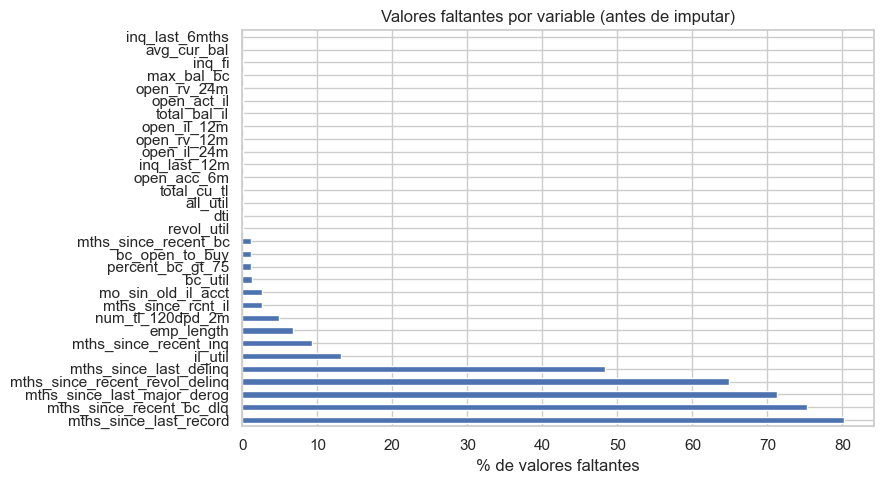

In [ ]:
if df_model is not None:
    faltantes = (df_model.isna().mean() * 100).sort_values(ascending=False)
    print("Porcentaje de valores faltantes por columna:")
    display(faltantes.round(2))

    plt.figure(figsize=(9, 5))
    faltantes[faltantes > 0].plot(kind="barh")
    plt.xlabel("% de valores faltantes")
    plt.title("Valores faltantes por variable (antes de imputar)")
    plt.tight_layout()
    plt.show()
else:
    print("df_model no disponible todavía.")


### 3.4 Definición de variables numéricas y categóricas

Como se vio en clase, la imputación **debe ajustarse solo con el set de entrenamiento**
(para no filtrar información del set de prueba). Por eso no imputamos aquí directamente
sobre `df_model`: en la Sección 3.6 comparamos distintas estrategias de imputación sobre
una muestra, y en la Sección 3.7 armamos el `ColumnTransformer` definitivo que se ajusta
únicamente con `X_train` dentro del `Pipeline` de cada modelo.

Se amplió el conjunto de variables predictoras, incorporando la mayor cantidad posible de variables seguras (disponibles al momento de originación y sin fuga de información). Para mantener la compatibilidad con distintas versiones del conjunto de datos, solo se incluyen las columnas que efectivamente están presentes en el CSV. Además, las variables específicas del co-solicitante (sec_app_* y *_joint) fueron sustituidas por la variable binaria es_solicitud_conjunta, simplificando su representación en el modelo.

In [ ]:
if df_model is not None:

    VARS_NUMERICAS = [c for c in [
        "loan_amnt", "term", "int_rate", "installment", "emp_length", "annual_inc",
        "dti", "delinq_2yrs", "open_acc", "pub_rec", "revol_bal", "revol_util",
        "total_acc", "fico_range_low", "fico_range_high", "inq_last_6mths",
        "mths_since_last_delinq", "mths_since_last_record", "mths_since_last_major_derog",
        "collections_12_mths_ex_med", "acc_now_delinq", "tot_coll_amt", "tot_cur_bal",
        "open_acc_6m", "open_act_il", "open_il_12m", "open_il_24m", "mths_since_rcnt_il",
        "total_bal_il", "il_util", "open_rv_12m", "open_rv_24m", "max_bal_bc", "all_util",
        "total_rev_hi_lim", "inq_fi", "total_cu_tl", "inq_last_12m",
        "acc_open_past_24mths", "avg_cur_bal", "bc_open_to_buy", "bc_util",
        "chargeoff_within_12_mths", "delinq_amnt", "mo_sin_old_il_acct",
        "mo_sin_old_rev_tl_op", "mo_sin_rcnt_rev_tl_op", "mo_sin_rcnt_tl", "mort_acc",
        "mths_since_recent_bc", "mths_since_recent_bc_dlq", "mths_since_recent_inq",
        "mths_since_recent_revol_delinq", "num_accts_ever_120_pd", "num_actv_bc_tl",
        "num_actv_rev_tl", "num_bc_sats", "num_bc_tl", "num_il_tl", "num_op_rev_tl",
        "num_rev_accts", "num_rev_tl_bal_gt_0", "num_sats", "num_tl_120dpd_2m",
        "num_tl_30dpd", "num_tl_90g_dpd_24m", "num_tl_op_past_12m", "pct_tl_nvr_dlq",
        "percent_bc_gt_75", "pub_rec_bankruptcies", "tax_liens", "tot_hi_cred_lim",
        "total_bal_ex_mort", "total_bc_limit", "total_il_high_credit_limit",
        "credit_history_months", "es_solicitud_conjunta",
    ] if c in df_model.columns]

    VARS_CATEGORICAS = [c for c in [
        "grade", "sub_grade", "home_ownership", "verification_status", "purpose",
        "addr_state", "initial_list_status", "disbursement_method",
        # nota: "application_type" queda fuera a propósito -- es redundante con
        # "es_solicitud_conjunta" (Sección 3.2.1), que ya codifica la misma información.
    ] if c in df_model.columns]

    print(f"Variables numéricas ({len(VARS_NUMERICAS)}):", VARS_NUMERICAS)
    print(f"\nVariables categóricas ({len(VARS_CATEGORICAS)}):", VARS_CATEGORICAS)
    print(f"\nTotal de variables predictoras: {len(VARS_NUMERICAS) + len(VARS_CATEGORICAS)} "
          f"(el paper reporta 151; la cifra final acá depende de qué columnas trajo la "
          f"versión del CSV descargada -- ver Sección 2.7).")

    X = df_model[VARS_NUMERICAS + VARS_CATEGORICAS].copy()
    y = df_model["default"].copy()
else:
    print("df_model no disponible todavía.")


Variables numéricas (77): ['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'nu

**Matriz de correlación:** el paper original (Fig. 2) incluye una matriz de
correlación entre variables numéricas para detectar multicolinealidad antes de
modelar. Replicamos ese análisis sobre nuestras variables numéricas.

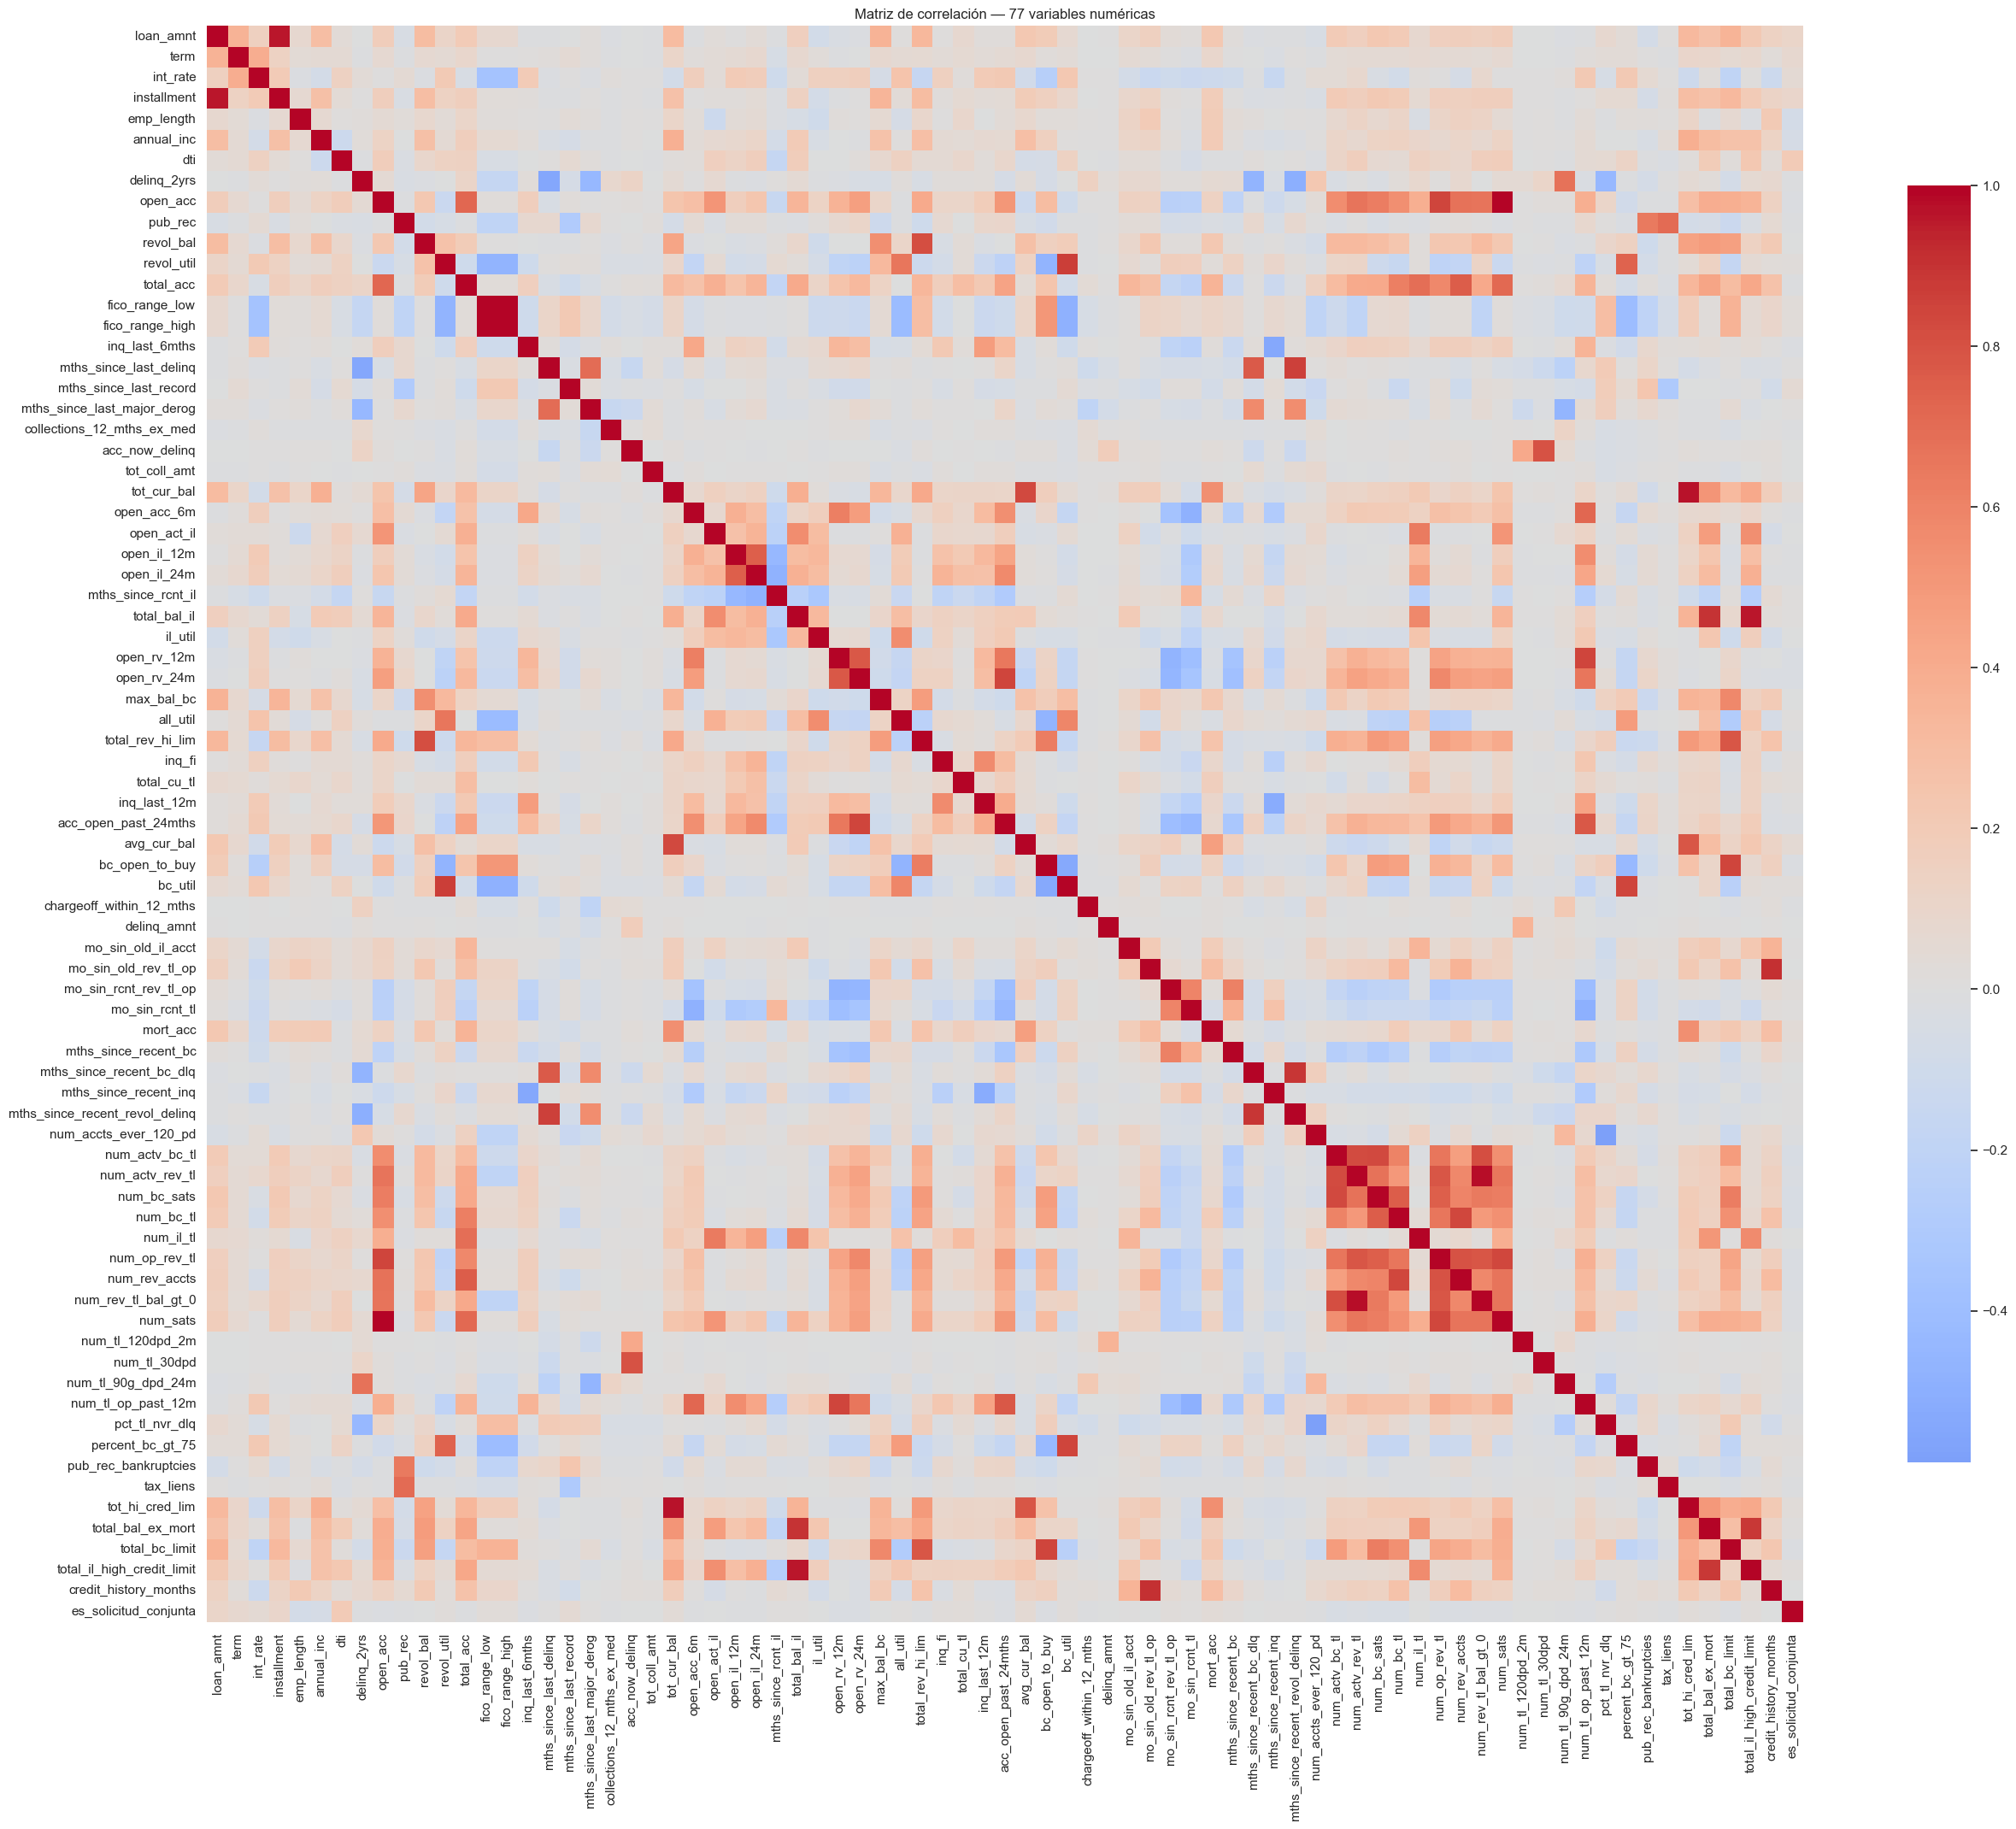

Pares de variables numéricas más correlacionados (|r| > 0.85):


fico_range_high                 fico_range_low                    1.000000
open_acc                        num_sats                          0.998701
num_actv_rev_tl                 num_rev_tl_bal_gt_0               0.976209
tot_cur_bal                     tot_hi_cred_lim                   0.966585
total_il_high_credit_limit      total_bal_il                      0.957293
installment                     loan_amnt                         0.956596
mo_sin_old_rev_tl_op            credit_history_months             0.911902
total_bal_ex_mort               total_bal_il                      0.898147
mths_since_recent_revol_delinq  mths_since_recent_bc_dlq          0.889536
total_bal_ex_mort               total_il_high_credit_limit        0.882958
revol_util                      bc_util                           0.866262
mths_since_last_delinq          mths_since_recent_revol_delinq    0.860778
dtype: float64

In [ ]:
if df_model is not None:
    matriz_corr = df_model[VARS_NUMERICAS].corr()

    # Con ~18 variables las anotaciones numéricas dentro de cada celda eran legibles;
    # con la lista ampliada (Sección 2.7) pueden ser >70 variables, así que las
    # desactivamos automáticamente para no saturar la figura (umbral: 25 variables).
    usar_anotaciones = len(VARS_NUMERICAS) <= 25
    lado = max(10, len(VARS_NUMERICAS) * 0.35)

    plt.figure(figsize=(lado, lado * 0.8))
    sns.heatmap(
        matriz_corr, annot=usar_anotaciones, fmt=".2f", cmap="coolwarm",
        center=0, square=True, cbar_kws={"shrink": 0.8},
        annot_kws={"size": 7} if usar_anotaciones else None,
    )
    plt.title(f"Matriz de correlación — {len(VARS_NUMERICAS)} variables numéricas")
    plt.tight_layout()
    plt.show()

    if not usar_anotaciones:
        # Con muchas variables, un heatmap sin números sirve para ver estructura general
        # (bloques de variables muy correlacionadas), pero para decisiones puntuales es
        # más útil listar los pares más correlacionados explícitamente:
        corr_pares = (
            matriz_corr.where(~np.eye(len(matriz_corr), dtype=bool))
            .abs().unstack().sort_values(ascending=False).drop_duplicates()
        )
        print("Pares de variables numéricas más correlacionados (|r| > 0.85):")
        display(corr_pares[corr_pares > 0.85].head(20))
else:
    print("df_model no disponible todavía.")


### 3.5 Split train/test estratificado

In [ ]:
if df_model is not None:
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    print("Train:", X_train.shape, " Test:", X_test.shape)
    print("\nProporción de default en train:", y_train.mean().round(4))
    print("Proporción de default en test :", y_test.mean().round(4))
else:
    print("df_model no disponible todavía.")


Train: (369940, 85)  Test: (92486, 85)

Proporción de default en train: 0.2323
Proporción de default en test : 0.2323


### 3.6 Comparación de estrategias de imputación (simple vs. KNN vs. Random Forest)

Antes de fijar con qué imputar las variables numéricas en el pipeline definitivo
(Sección 3.7), comparamos tres estrategias vistas en clase:

1. **Simple** (`SimpleImputer`, mediana): rápida, pero ignora la relación entre
   variables.
2. **KNN** (`KNNImputer`): imputa cada valor faltante con el promedio (ponderado
   por distancia) de sus *k* vecinos más parecidos en las demás variables.
3. **Random Forest / Iterative** (`IterativeImputer` con un `RandomForestRegressor`
   como estimador interno, al estilo *missForest*): imputa cada variable
   entrenando un Random Forest que la predice a partir de las demás, iterando
   varias veces.

**Metodología (validación por enmascaramiento):** tomamos una muestra de filas de
`X_train` que **sí tienen** todos los valores numéricos, ocultamos artificialmente
~15% de esas celdas (simulando faltantes al azar), imputamos con cada método y
comparamos contra el valor real oculto usando **NRMSE** (RMSE normalizado por la
desviación estándar de cada variable, para que columnas de distinta escala —por
ejemplo `loan_amnt` en miles vs. `dti` en decenas— aporten de forma comparable).

/Users/benjaminromeroneubauer/mi_proyecto/.venv/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,NRMSE promedio
Iterative (Random Forest),0.5210
KNN (k=5),0.9553
Simple (mediana),1.0169


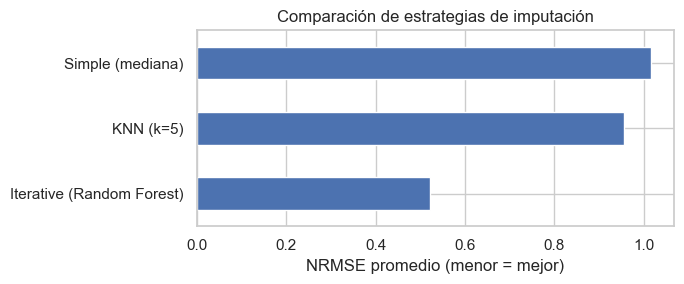


Mejor estrategia de imputación según NRMSE: Iterative (Random Forest)


In [ ]:
if df_model is not None:
    from sklearn.impute import SimpleImputer, KNNImputer
    from sklearn.experimental import enable_iterative_imputer  # noqa: F401 (habilita IterativeImputer)
    from sklearn.impute import IterativeImputer
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import mean_squared_error
    from sklearn.base import clone

    N_MUESTRA_IMPUTACION = 5000  # bajado de 8000: con la lista ampliada de variables
    # (Sección 2.7) hay muchas más columnas para KNN/IterativeImputer, así que se
    # reduce la muestra para mantener el tiempo de cómputo razonable; ajustar según
    # tu máquina.
    PROP_ENMASCARADO = 0.15

    # Nos quedamos solo con filas sin NaN en las variables numéricas, para tener
    # un "terreno de verdad" (ground truth) contra el cual comparar
    completo = X_train[VARS_NUMERICAS].dropna()
    muestra = completo.sample(
        n=min(N_MUESTRA_IMPUTACION, len(completo)), random_state=RANDOM_STATE
    ).copy()

    rng = np.random.RandomState(RANDOM_STATE)
    mask_enmascarado = rng.rand(*muestra.shape) < PROP_ENMASCARADO
    muestra_con_nan = muestra.mask(mask_enmascarado)

    imputadores_candidatos = {
        "Simple (mediana)": SimpleImputer(strategy="median"),
        "KNN (k=5)": KNNImputer(n_neighbors=5),
        "Iterative (Random Forest)": IterativeImputer(
            estimator=RandomForestRegressor(
                n_estimators=20, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1
            ),
            max_iter=5, random_state=RANDOM_STATE,
        ),
    }

    resultados_imputacion = {}
    stds = muestra.std()

    for nombre, imputador in imputadores_candidatos.items():
        imputado = pd.DataFrame(
            clone(imputador).fit_transform(muestra_con_nan),
            columns=muestra.columns, index=muestra.index,
        )
        nrmses_por_columna = []
        for col in muestra.columns:
            idx = mask_enmascarado[:, muestra.columns.get_loc(col)]
            if idx.sum() == 0:
                continue
            y_true = muestra[col].values[idx]
            y_pred = imputado[col].values[idx]
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            nrmses_por_columna.append(rmse / (stds[col] + 1e-9))
        resultados_imputacion[nombre] = np.mean(nrmses_por_columna)

    tabla_imputacion = (
        pd.DataFrame.from_dict(resultados_imputacion, orient="index", columns=["NRMSE promedio"])
        .sort_values("NRMSE promedio")
    )
    display(tabla_imputacion.round(4))

    tabla_imputacion.plot(kind="barh", legend=False, figsize=(7, 3))
    plt.xlabel("NRMSE promedio (menor = mejor)")
    plt.title("Comparación de estrategias de imputación")
    plt.tight_layout()
    plt.show()

    MEJOR_IMPUTADOR_NOMBRE = tabla_imputacion.index[0]
    print(f"\nMejor estrategia de imputación según NRMSE: {MEJOR_IMPUTADOR_NOMBRE}")
else:
    print("df_model no disponible todavía.")


### 3.7 Pipeline de preprocesamiento definitivo (imputación + escalamiento + codificación) y balanceo con RUS

Se arma un `ColumnTransformer` con dos ramas:

- Numéricas: imputador elegido más abajo → `StandardScaler`.
- Categóricas: `SimpleImputer(constante "Desconocido")` → `OneHotEncoder`.

Este preprocesador se combina, dentro de un `imblearn.pipeline.Pipeline`, con
**`RandomUnderSampler` (RUS)** para balancear las clases — solo en el momento de
entrenar (`fit`), nunca se aplica sobre el set de prueba, que debe reflejar la
distribución real de clases.

**Por qué RUS y no SMOTE:**
1. **Fidelidad al paper**: la combinación ganadora de Moscato et al. (2021) es
   **Random Forest + RUS**, no sobremuestreo. Usar RUS nos permite comparar
   "manzanas con manzanas" en la Sección 7.
2. **Eficiencia**: SMOTE genera millones de filas sintéticas para igualar la clase
   mayoritaria; RUS, en cambio, **reduce** la clase mayoritaria al tamaño de la
   minoritaria, resultando en un train set mucho más pequeño y rápido de entrenar.

**Sobre el imputador numérico — costo computacional a gran escala:** que un método
haya ganado en la muestra chica de la Sección 3.6 **no garantiza** que sea viable
aplicarlo a `X_train` completo. `KNNImputer` e `IterativeImputer` con Random Forest
pueden volverse extremadamente lentos con ~1-2 millones de filas en una máquina con
poca RAM. Por eso dejamos un interruptor explícito:

- `USAR_IMPUTACION_AVANZADA = False` (default): usa `SimpleImputer` (mediana) en
  el pipeline completo, aunque KNN o Random Forest hayan ganado en la Sección 3.6
  — se deja documentado cuál ganó, para discutirlo en la Sección 7, priorizando
  que el cuaderno corra en un tiempo razonable.
- `USAR_IMPUTACION_AVANZADA = True`: usa la estrategia ganadora de la Sección 3.6
  también en el pipeline completo. Actívalo solo si tu máquina lo soporta.

In [ ]:
if df_model is not None:
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.under_sampling import RandomUnderSampler

    USAR_IMPUTACION_AVANZADA = False  # cambiar a True solo si tu máquina lo soporta

    if USAR_IMPUTACION_AVANZADA:
        imputador_numerico_final = clone(imputadores_candidatos[MEJOR_IMPUTADOR_NOMBRE])
        print(f"Usando en el pipeline completo: {MEJOR_IMPUTADOR_NOMBRE}")
    else:
        imputador_numerico_final = SimpleImputer(strategy="median")
        print("Usando en el pipeline completo: Simple (mediana), por costo computacional.")
        print(f"(La Sección 3.6 sugiere que '{MEJOR_IMPUTADOR_NOMBRE}' imputa mejor en la muestra chica.)")

    transformador_numerico = Pipeline(steps=[
        ("imputar", imputador_numerico_final),
        ("escalar", StandardScaler()),
    ])

    transformador_categorico = Pipeline(steps=[
        ("imputar", SimpleImputer(strategy="constant", fill_value="Desconocido")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocesador = ColumnTransformer(transformers=[
        ("num", transformador_numerico, VARS_NUMERICAS),
        ("cat", transformador_categorico, VARS_CATEGORICAS),
    ])

    # Random Under-Sampling: reduce la clase mayoritaria (pagados) al tamaño de la
    # clase minoritaria (default), en vez de generar sintéticos como hacía SMOTE.
    rus = RandomUnderSampler(random_state=RANDOM_STATE)

    print("\nPreprocesador (imputación + escalamiento + codificación) listo.")
    print(preprocesador)
    print("\nSampler de balanceo de clases: RandomUnderSampler (RUS)")
else:
    print("df_model no disponible todavía.")


Usando en el pipeline completo: Simple (mediana), por costo computacional.
(La Sección 3.6 sugiere que 'Iterative (Random Forest)' imputa mejor en la muestra chica.)

Preprocesador (imputación + escalamiento + codificación) listo.
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputar',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalar',
                                                  StandardScaler())]),
                                 ['loan_amnt', 'term', 'int_rate',
                                  'installment', 'emp_length', 'annual_inc',
                                  'dti', 'delinq_2yrs', 'open_acc', 'pub_rec',
                                  'revol_bal', 'revol_util', 'total_acc',
                                  'fico_range_low', 'fico_range_high',
                                  'inq_last_6mths', 'mths_since_last_d...
         

## 3.8 Selección de variables por regularización L1 (Lasso)

Con 85 variables predictoras es difícil saber, a simple vista, cuáles pesan de verdad — una
regresión logística con penalización L1 entrega justamente eso: una lista ordenada de
variables por importancia, útil como insumo directo para la exposición oral.

**Metodología:**

1. Se transforma `X_train` con el `preprocesador` ya definido en la Sección 3.7
   (imputación + escalamiento + codificación One-Hot).
2. Se ajusta `LogisticRegression(penalty="l1", solver="liblinear")`, que empuja a cero
   los coeficientes de variables poco informativas. Se usa `class_weight="balanced"` en
   vez de RUS específicamente para esta selección, para aprovechar el 100% de las filas
   de `X_train` al estimar los coeficientes.
3. Como cada categoría de una variable categórica genera una columna dummy tras el
   One-Hot, se agrega la importancia (valor absoluto del coeficiente) **por variable
   original**, sumando sobre todas sus columnas transformadas.
4. `SelectFromModel` sobre el mismo modelo cuantifica, además, cuántas columnas
   transformadas quedaron con coeficiente distinto de cero (ganancia de eficiencia).

Este ranking es puramente informativo (no se usa para entrenar un modelo reducido);
queda como mejora futura evaluar si un Random Forest entrenado solo con las variables
top-N pierde desempeño relevante frente al de 85 variables.


SelectFromModel (L1): 154 de 194 columnas transformadas quedaron con coeficiente distinto de cero (79.4%).

Ranking de variables originales por importancia L1 (top 25) -- lista para la exposición oral:


addr_state                    5.7585
sub_grade                     1.4423
purpose                       1.2016
grade                         1.1014
home_ownership                0.3437
term                          0.2082
credit_history_months         0.1835
dti                           0.1820
int_rate                      0.1749
verification_status           0.1519
total_bc_limit                0.1387
open_rv_12m                   0.1355
num_actv_rev_tl               0.1336
mo_sin_old_rev_tl_op          0.1297
installment                   0.1165
num_tl_op_past_12m            0.1155
open_rv_24m                   0.1071
total_il_high_credit_limit    0.1043
total_acc                     0.1004
fico_range_low                0.0840
mort_acc                      0.0796
total_bal_il                  0.0747
percent_bc_gt_75              0.0731
avg_cur_bal                   0.0653
delinq_2yrs                   0.0622
Name: importancia_L1_(suma |coef|), dtype: float64

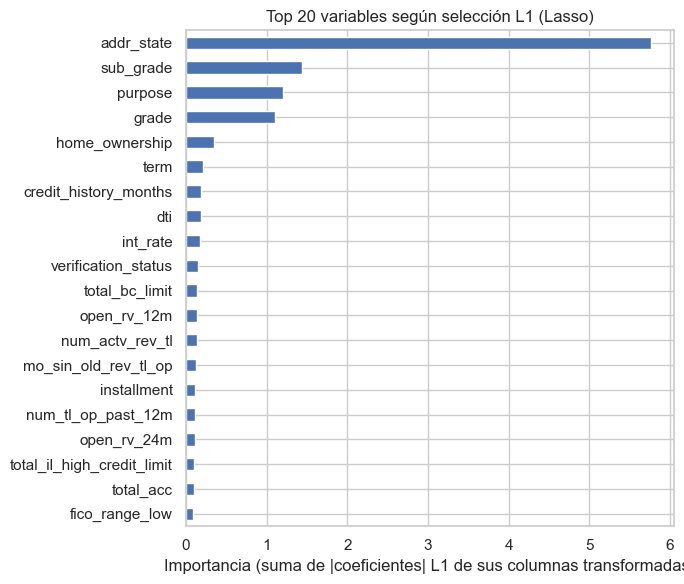


Top 20 variables (VARS_TOP_L1): ['addr_state', 'sub_grade', 'purpose', 'grade', 'home_ownership', 'term', 'credit_history_months', 'dti', 'int_rate', 'verification_status', 'total_bc_limit', 'open_rv_12m', 'num_actv_rev_tl', 'mo_sin_old_rev_tl_op', 'installment', 'num_tl_op_past_12m', 'open_rv_24m', 'total_il_high_credit_limit', 'total_acc', 'fico_range_low']


In [ ]:
if df_model is not None:
    from sklearn.linear_model import LogisticRegression as _LogRegL1
    from sklearn.feature_selection import SelectFromModel
    from sklearn.base import clone as _clone

    preprocesador_l1_fit = _clone(preprocesador)
    X_train_transformado = preprocesador_l1_fit.fit_transform(X_train)
    nombres_features_transformadas = preprocesador_l1_fit.get_feature_names_out()

    # 'penalty' quedó deprecado en sklearn 1.8 (se elimina en 1.10) a favor de
    # 'l1_ratio': l1_ratio=1 equivale a penalty="l1" puro, l1_ratio=0 a penalty="l2".
    logreg_l1 = _LogRegL1(
        l1_ratio=1, solver="liblinear", C=0.05, max_iter=3000,
        class_weight="balanced", random_state=RANDOM_STATE,
    )
    logreg_l1.fit(X_train_transformado, y_train)

    selector_l1 = SelectFromModel(logreg_l1, prefit=True, threshold=1e-6)
    mascara_seleccion = selector_l1.get_support()
    n_total_transf = len(nombres_features_transformadas)
    n_seleccionadas = int(mascara_seleccion.sum())
    print(f"SelectFromModel (L1): {n_seleccionadas} de {n_total_transf} columnas "
          f"transformadas quedaron con coeficiente distinto de cero "
          f"({n_seleccionadas / n_total_transf:.1%}).")

    def _variable_original(nombre_transformado, vars_numericas, vars_categoricas):
        """Mapea 'num__loan_amnt' -> 'loan_amnt' y 'cat__grade_A' -> 'grade'."""
        if nombre_transformado.startswith("num__"):
            return nombre_transformado[len("num__"):]
        if nombre_transformado.startswith("cat__"):
            resto = nombre_transformado[len("cat__"):]
            candidatos = [v for v in vars_categoricas if resto.startswith(v)]
            if candidatos:
                return max(candidatos, key=len)
            return resto
        return nombre_transformado

    coeficientes = np.abs(logreg_l1.coef_).ravel()
    importancia_por_var = {}
    for nombre_t, coef in zip(nombres_features_transformadas, coeficientes):
        var_original = _variable_original(nombre_t, VARS_NUMERICAS, VARS_CATEGORICAS)
        importancia_por_var[var_original] = importancia_por_var.get(var_original, 0.0) + coef

    tabla_importancia_l1 = (
        pd.Series(importancia_por_var, name="importancia_L1_(suma |coef|)")
        .sort_values(ascending=False)
    )
    print("\nRanking de variables originales por importancia L1 (top 25) -- lista para "
          "la exposición oral:")
    display(tabla_importancia_l1.head(25).round(4))

    tabla_importancia_l1.head(20).sort_values().plot(kind="barh", figsize=(7, 6))
    plt.xlabel("Importancia (suma de |coeficientes| L1 de sus columnas transformadas)")
    plt.title("Top 20 variables según selección L1 (Lasso)")
    plt.tight_layout()
    plt.show()

    VARS_TOP_L1 = [v for v in tabla_importancia_l1[tabla_importancia_l1 > 0].index[:20]]
    print(f"\nTop 20 variables (VARS_TOP_L1): {VARS_TOP_L1}")
else:
    print("df_model no disponible todavía.")


## 4. Modelos del paper (Moscato et al., 2021)

Moscato, Picariello & Sperlí (2021) comparan varios algoritmos de credit scoring
(regresión logística, árboles de decisión, random forest, redes neuronales) combinados
con distintas técnicas de muestreo. Siguiendo la recomendación de la Sección 5.1 de la
pauta, replicamos un subconjunto representativo de **2 modelos**, ambos con **RUS** como
técnica de balanceo (la configuración ganadora del paper):

- **Regresión logística + RUS**: modelo base/clásico, altamente interpretable.
- **Random Forest + RUS**: la combinación destacada por los autores como la de mejor
  desempeño (AUC ≈ 71,7%, accuracy ≈ 64%, recall ≈ 63%).

Ambos se entrenan dentro de un `Pipeline` que incluye el preprocesador de la
Sección 3.7 y el balanceo con RUS, de modo que el flujo completo
(imputación → escalamiento/codificación → RUS → modelo) se ajusta una sola vez
con `fit(X_train, y_train)`.

### 4.1 Función auxiliar de evaluación

Se agrega **Specificity** a las métricas calculadas, ya que el paper reporta
AUC, Sensitivity (= recall) y Specificity explícitamente.


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)

resultados = []  # aquí se acumulan las métricas de todos los modelos
curvas_roc = {}  # aquí se guardan (fpr, tpr) de cada modelo para graficar juntas


def evaluar_modelo(nombre, pipeline, X_test, y_test, resultados, curvas_roc):
    """Calcula métricas estándar de clasificación y las agrega a `resultados`.

    Incluye Specificity (TNR), FP-Rate y G-Mean para alinear las métricas con
    las que reporta el paper original en su Tabla 4 (AUC, TPR, TNR, FP-Rate,
    G-Mean, ACC).
    """
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")  # TNR
    fp_rate = fp / (tn + fp) if (tn + fp) > 0 else float("nan")       # = 1 - TNR
    recall = recall_score(y_test, y_pred)                              # TPR / Sensitivity
    g_mean = np.sqrt(recall * specificity) if recall >= 0 and specificity >= 0 else float("nan")

    metrica = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall,          # = TPR / Sensitivity
        "specificity": specificity,  # = TNR
        "fp_rate": fp_rate,
        "g_mean": g_mean,
        "f1": f1_score(y_test, y_pred),
        "auc_roc": roc_auc_score(y_test, y_proba),
    }
    resultados.append(metrica)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    curvas_roc[nombre] = (fpr, tpr, metrica["auc_roc"])

    print(f"--- {nombre} ---")
    for k, v in metrica.items():
        if k != "modelo":
            print(f"  {k:12s}: {v:.4f}")

    ConfusionMatrixDisplay(cm, display_labels=["Pagado", "Default"]).plot(cmap="Blues")
    plt.title(f"Matriz de confusión — {nombre}")
    plt.show()

    return metrica


### 4.2 Modelo 1 — Regresión logística + RUS

--- Regresión logística + RUS ---
  accuracy    : 0.6472
  precision   : 0.3623
  recall      : 0.6829
  specificity : 0.6364
  fp_rate     : 0.3636
  g_mean      : 0.6592
  f1          : 0.4735
  auc_roc     : 0.7199


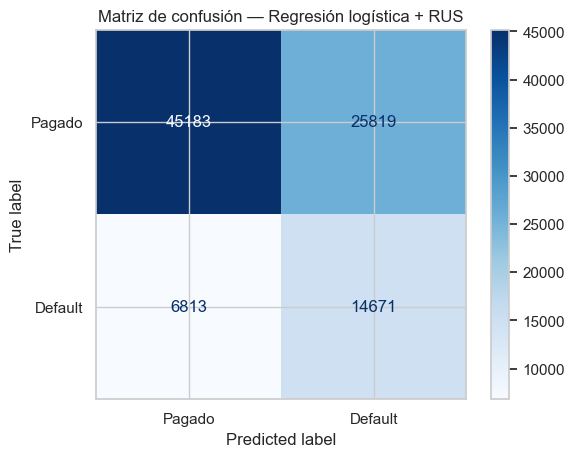

In [ ]:
if df_model is not None:
    from sklearn.linear_model import LogisticRegression

    pipeline_logreg = ImbPipeline(steps=[
        ("preprocesador", preprocesador),
        ("rus", rus),
        ("clasificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])

    pipeline_logreg.fit(X_train, y_train)

    metrica_logreg = evaluar_modelo(
        "Regresión logística + RUS", pipeline_logreg, X_test, y_test, resultados, curvas_roc
    )
else:
    print("df_model no disponible todavía.")


### 4.3 Modelo 2 — Random Forest + RUS

**Por qué estos hiperparámetros:** con 85 variables disponibles, límites más
conservadores (`max_depth` bajo, `min_samples_leaf` alto) no dejaban que el modelo
aprovechara la señal adicional -- la specificity de RF no mejoró nada al pasar de 18 a
85 variables, a diferencia de LR y XGBoost (ver comparación en la Sección 6). Se usa
`max_depth=25`, `min_samples_leaf=2` y `n_estimators=250` (más árboles para compensar
la mayor varianza de árboles más profundos).


--- Random Forest + RUS ---
  accuracy    : 0.6428
  precision   : 0.3588
  recall      : 0.6833
  specificity : 0.6306
  fp_rate     : 0.3694
  g_mean      : 0.6564
  f1          : 0.4705
  auc_roc     : 0.7183


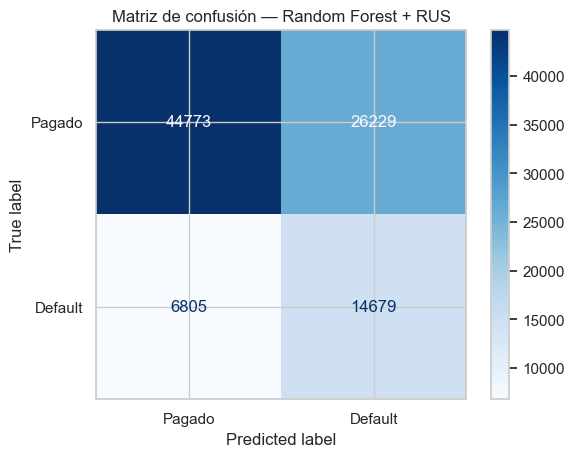

In [ ]:
if df_model is not None:
    from sklearn.ensemble import RandomForestClassifier

    pipeline_rf = ImbPipeline(steps=[
        ("preprocesador", preprocesador),
        ("rus", rus),
        ("clasificador", RandomForestClassifier(
            n_estimators=250,       # antes 150 -- compensa mayor profundidad
            max_depth=25,           # antes 15 -- permite aprovechar más señal
            min_samples_leaf=2,     # antes 5 -- menos restrictivo
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])

    pipeline_rf.fit(X_train, y_train)

    metrica_rf = evaluar_modelo(
        "Random Forest + RUS", pipeline_rf, X_test, y_test, resultados, curvas_roc
    )
else:
    print("df_model no disponible todavía.")


### 4.3.1 Random Forest con los hiperparámetros literales del paper

En la Sección 7.3 identificamos que ni el ajuste manual de hiperparámetros (Sección 4.3)
ni la búsqueda formal con `GridSearchCV` (Sección 4.5) lograron cerrar la brecha de
specificity de Random Forest frente al paper (0,631 vs. 0,680). La explicación que queda
sin descartar es que Moscato et al. (2021) reportan hiperparámetros mucho más
conservadores que los nuestros: `RandomForestClassifier(n_estimators=100, max_depth=4)`
-- un bosque bastante más superficial que el usado en las Secciones 4.3/4.5
(`max_depth=25` o `None`).

Entrenamos aquí esa configuración **exacta**, con RUS (la misma técnica de balanceo de
la combinación ganadora del paper), para aislar el efecto de la profundidad del árbol:
si esta versión recupera specificity más cercana a 0,680 (probablemente a costa de
menor recall/AUC, como es esperable con árboles tan poco profundos), es evidencia de
que la brecha observada en las Secciones 4.3/4.5 viene principalmente de usar árboles
más profundos que los del paper -- no de las variables ni del umbral de decisión
(ambos ya descartados en la Sección 7.3). El resultado se discute en la Sección 7.3.


--- Random Forest + RUS (hiperparámetros literales del paper) ---
  accuracy    : 0.6024
  precision   : 0.3346
  recall      : 0.7198
  specificity : 0.5668
  fp_rate     : 0.4332
  g_mean      : 0.6387
  f1          : 0.4568
  auc_roc     : 0.7044


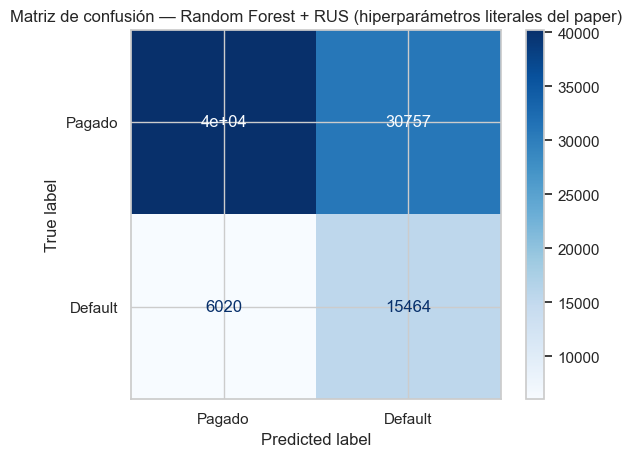

In [ ]:
if df_model is not None:
    from sklearn.ensemble import RandomForestClassifier

    pipeline_rf_paper = ImbPipeline(steps=[
        ("preprocesador", preprocesador),
        ("rus", RandomUnderSampler(random_state=RANDOM_STATE)),
        ("clasificador", RandomForestClassifier(
            n_estimators=100,   # hiperparámetro EXACTO reportado por Moscato et al. (2021)
            max_depth=4,        # ídem -- bosque deliberadamente superficial
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])

    pipeline_rf_paper.fit(X_train, y_train)

    metrica_rf_paper = evaluar_modelo(
        "Random Forest + RUS (hiperparámetros literales del paper)",
        pipeline_rf_paper, X_test, y_test, resultados, curvas_roc,
    )
else:
    print("df_model no disponible todavía.")


### 4.4 Random Forest + IHT (comparación adicional)

El paper compara **RUS** e **IHT (Instance Hardness Threshold)** como dos estrategias
de submuestreo distintas (Tabla 3), y reporta ambas combinaciones para cada clasificador
(Tabla 4: LR-IHT, RF-IHT). Agregamos aquí **Random Forest + IHT** como comparación
directa contra Random Forest + RUS (Sección 4.3), usando exactamente el mismo
clasificador (mismos hiperparámetros relajados) — así cualquier diferencia de
desempeño entre ambas versiones se puede atribuir a la técnica de submuestreo, no a
otra cosa.

**Diferencia clave con RUS:** RUS descarta muestras de la clase mayoritaria al azar.
IHT en cambio entrena un clasificador auxiliar y descarta primero las muestras
"fáciles" de clasificar (donde el modelo está muy seguro), quedándose con los casos más
informativos para definir la frontera de decisión. Es más costoso computacionalmente
(hay que entrenar ese clasificador auxiliar antes de submuestrear), pero según el
paper logra mayor specificity a costa de menor recall (comparar la Tabla 4: LR-IHT
tiene TNR = 0,877 pero TPR = solo 0,350, muy distinto al balance de RUS) — justo la
dirección en la que a nuestro Random Forest le está costando mejorar (ver Sección 6).


--- Random Forest + IHT ---
  accuracy    : 0.4795
  precision   : 0.2934
  recall      : 0.8810
  specificity : 0.3580
  fp_rate     : 0.6420
  g_mean      : 0.5616
  f1          : 0.4402
  auc_roc     : 0.6865


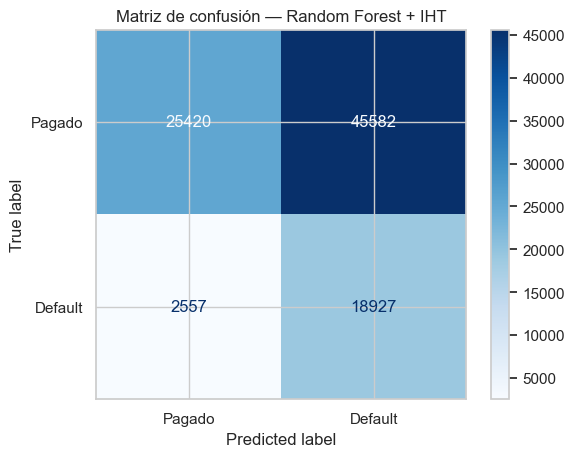

In [ ]:
if df_model is not None:
    from imblearn.under_sampling import InstanceHardnessThreshold

    # IHT estima, con un clasificador auxiliar, qué tan "difícil" es clasificar
    # correctamente cada muestra de la clase mayoritaria, y descarta primero las más
    # fáciles (las que aportan menos información para la frontera de decisión) --
    # a diferencia de RUS, que descarta al azar. Usamos un RF chico como estimador
    # auxiliar (estándar en la literatura e igual al que usa imblearn por defecto).
    iht = InstanceHardnessThreshold(
        estimator=RandomForestClassifier(
            n_estimators=50, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
        ),
        random_state=RANDOM_STATE,
    )

    pipeline_rf_iht = ImbPipeline(steps=[
        ("preprocesador", preprocesador),
        ("iht", iht),
        ("clasificador", RandomForestClassifier(
            n_estimators=250, max_depth=25, min_samples_leaf=2,
            n_jobs=-1, random_state=RANDOM_STATE,
        )),
    ])

    pipeline_rf_iht.fit(X_train, y_train)

    metrica_rf_iht = evaluar_modelo(
        "Random Forest + IHT", pipeline_rf_iht, X_test, y_test, resultados, curvas_roc
    )
else:
    print("df_model no disponible todavía.")


## 4.5 Búsqueda formal de hiperparámetros (`GridSearchCV`)

Los hiperparámetros de Random Forest usados en la Sección 4.3 (`max_depth=25`,
`min_samples_leaf=2`, `n_estimators=250`) fueron un ajuste **manual**, motivado por el
hallazgo de la Sección 7.2 (RF no cerraba la brecha de specificity), pero no una
búsqueda sistemática — limitación que se declaraba explícitamente en la Sección 7.5.
Se reemplaza aquí ese ajuste manual por un `GridSearchCV` formal, para Regresión
Logística y Random Forest (los dos modelos que usan RUS con hiperparámetros propios;
XGBoost ya no usa RUS, e IHT combinado con `GridSearchCV` sería extremadamente
costoso -- entrena un clasificador auxiliar en cada ajuste del grid -- así que no
se incluye en este cuaderno).

**Métrica de selección:** en vez del `scoring` por defecto (accuracy), se define un
`scorer` propio de **G-Mean** (`sqrt(recall × specificity)`), porque es la métrica que
mejor refleja el objetivo real del trabajo: un buen balance entre detectar defaults
(recall) y no rechazar buenos pagadores (specificity) — la misma métrica que venimos
usando para comparar contra el paper en las Secciones 6-6.2.

**Costo computacional:** `cv=3` (en vez de 5, como en la Sección 6.1) para acotar el
número de ajustes — con el grid de Random Forest (2 × 3 × 3 = 18 combinaciones × 3
folds = 54 entrenamientos de RF sobre datos balanceados por RUS) ya es la celda más
cara del cuaderno.


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Random Forest -- mejores hiperparámetros (GridSearchCV, scoring=G-Mean):
  {'clasificador__max_depth': None, 'clasificador__min_samples_leaf': 5, 'clasificador__n_estimators': 250}  (G-Mean CV = 0.6569)
  Config manual de la Sección 4.3 (max_depth=25, min_samples_leaf=2, n_estimators=250) -- comparar contra la ganadora de arriba.
--- Random Forest + RUS (GridSearchCV) ---
  accuracy    : 0.6428
  precision   : 0.3586
  recall      : 0.6819
  specificity : 0.6310
  fp_rate     : 0.3690
  g_mean      : 0.6560
  f1          : 0.4701
  auc_roc     : 0.7193


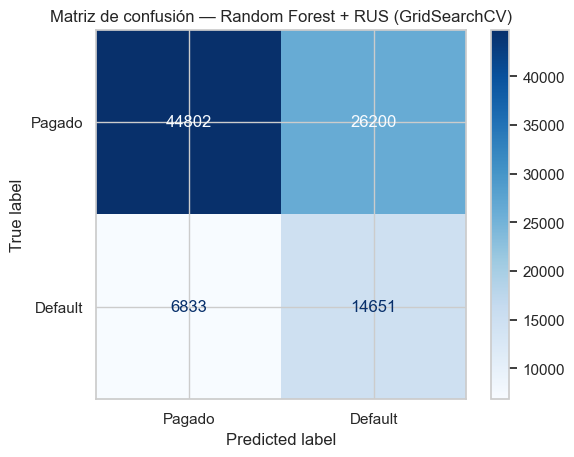

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Regresión logística -- mejores hiperparámetros (GridSearchCV, scoring=G-Mean):
  {'clasificador__C': 0.01, 'clasificador__l1_ratio': 0}  (G-Mean CV = 0.6580)
--- Regresión logística + RUS (GridSearchCV) ---
  accuracy    : 0.6464
  precision   : 0.3618
  recall      : 0.6830
  specificity : 0.6354
  fp_rate     : 0.3646
  g_mean      : 0.6588
  f1          : 0.4730
  auc_roc     : 0.7196


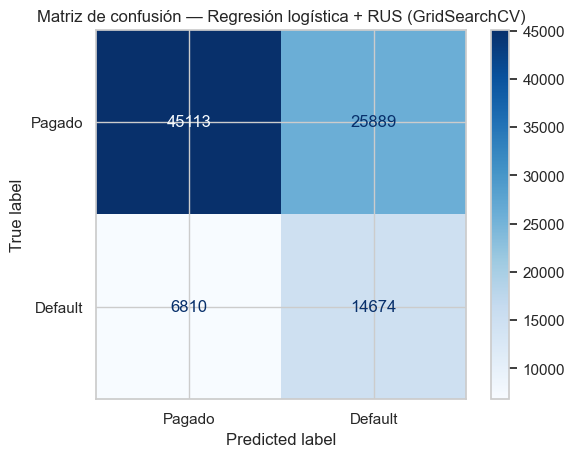

In [ ]:
if df_model is not None:
    from sklearn.model_selection import GridSearchCV, StratifiedKFold
    from sklearn.metrics import make_scorer
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.base import clone

    def _g_mean_desde_predicciones(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        return float(np.sqrt(rec * spec))

    g_mean_scorer = make_scorer(_g_mean_desde_predicciones)
    cv_gscv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    # --- Random Forest ---------------------------------------------------
    pipeline_rf_base = ImbPipeline(steps=[
        ("preprocesador", clone(preprocesador)),
        ("rus", RandomUnderSampler(random_state=RANDOM_STATE)),
        ("clasificador", RandomForestClassifier(n_jobs=1, random_state=RANDOM_STATE)),
    ])
    grid_rf = {
        "clasificador__n_estimators": [150, 250],
        "clasificador__max_depth": [15, 25, None],
        "clasificador__min_samples_leaf": [1, 2, 5],
    }
    busqueda_rf = GridSearchCV(
        pipeline_rf_base, grid_rf, scoring=g_mean_scorer, cv=cv_gscv,
        n_jobs=-1, verbose=1, refit=True,
    )
    busqueda_rf.fit(X_train, y_train)
    print("Random Forest -- mejores hiperparámetros (GridSearchCV, scoring=G-Mean):")
    print(f"  {busqueda_rf.best_params_}  (G-Mean CV = {busqueda_rf.best_score_:.4f})")
    print(f"  Config manual de la Sección 4.3 (max_depth=25, min_samples_leaf=2, "
          f"n_estimators=250) -- comparar contra la ganadora de arriba.")

    pipeline_rf_gscv = busqueda_rf.best_estimator_  # ya reentrenado con todo X_train
    metrica_rf_gscv = evaluar_modelo(
        "Random Forest + RUS (GridSearchCV)", pipeline_rf_gscv, X_test, y_test,
        resultados, curvas_roc,
    )

    # --- Regresión logística ----------------------------------------------
    pipeline_lr_base = ImbPipeline(steps=[
        ("preprocesador", clone(preprocesador)),
        ("rus", RandomUnderSampler(random_state=RANDOM_STATE)),
        ("clasificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])
    # 'penalty' quedó deprecado en sklearn 1.8 -- l1_ratio=0 equivale a penalty="l2"
    # (además, desde 1.8 el default de l1_ratio ya es 0.0, o sea L2 puro).
    grid_lr = {
        "clasificador__C": [0.01, 0.1, 1, 10],
        "clasificador__l1_ratio": [0],
    }
    busqueda_lr = GridSearchCV(
        pipeline_lr_base, grid_lr, scoring=g_mean_scorer, cv=cv_gscv,
        n_jobs=-1, verbose=1, refit=True,
    )
    busqueda_lr.fit(X_train, y_train)
    print("\nRegresión logística -- mejores hiperparámetros (GridSearchCV, scoring=G-Mean):")
    print(f"  {busqueda_lr.best_params_}  (G-Mean CV = {busqueda_lr.best_score_:.4f})")

    pipeline_logreg_gscv = busqueda_lr.best_estimator_
    metrica_lr_gscv = evaluar_modelo(
        "Regresión logística + RUS (GridSearchCV)", pipeline_logreg_gscv, X_test, y_test,
        resultados, curvas_roc,
    )
else:
    print("df_model no disponible todavía.")


## 5. Modelo adicional propuesto por el grupo — XGBoost

**Justificación (Sección 5.2 de la pauta):** proponemos **XGBoost** (`XGBClassifier`),
un modelo de *gradient boosting* de árboles, distinto a los replicados del paper
(regresión logística y random forest, ambos con RUS). Lo elegimos por tres razones:

1. **Boosting en vez de bagging**: a diferencia de Random Forest (que promedia
   muchos árboles independientes), XGBoost construye árboles secuenciales, cada
   uno corrigiendo los errores del anterior — suele capturar mejor interacciones
   no lineales (p. ej. entre `dti`, `int_rate` y `grade`).
2. **Maneja valores faltantes de forma nativa**: `XGBClassifier` aprende, para cada
   nodo, la mejor dirección a tomar cuando un valor es `NaN`, lo que permite
   comparar el efecto de *no* imputar frente a la imputación explícita de la
   Sección 4. Como consecuencia, aquí **no usamos RUS** (que descartaría
   información real al submuestrear) **ni SMOTE** (que no acepta `NaN`): el
   desbalance de clases se compensa con el parámetro nativo `scale_pos_weight`,
   otra estrategia estándar y válida, que además diversifica las técnicas de
   balanceo comparadas en el trabajo (RUS para LR/RF, ponderación nativa para
   boosting) — en la línea de lo que hace el propio paper, que compara RUS
   contra IHT (Instance Hardness Threshold) según el modelo.
3. Es un **benchmark estándar de la industria** para *credit scoring*, visto en
   clase, y no utilizado por Moscato et al. (2021), lo que lo hace un contraste
   interesante frente a Random Forest.

scale_pos_weight = 3.305
--- XGBoost ---
  accuracy    : 0.6602
  precision   : 0.3738
  recall      : 0.6852
  specificity : 0.6527
  fp_rate     : 0.3473
  g_mean      : 0.6687
  f1          : 0.4837
  auc_roc     : 0.7325


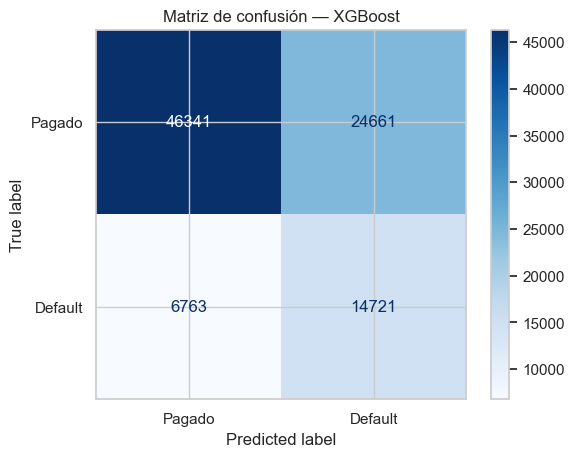

In [ ]:
if df_model is not None:
    from xgboost import XGBClassifier

    # Para este modelo NO usamos el preprocesador con imputación: dejamos los NaN
    # tal cual (solo codificamos las categóricas -> categorías nativas de XGBoost)
    # para aprovechar el manejo nativo de faltantes.
    preprocesador_xgb = ColumnTransformer(transformers=[
        ("num", "passthrough", VARS_NUMERICAS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), VARS_CATEGORICAS),
    ])

    # scale_pos_weight = (# negativos) / (# positivos) en el set de entrenamiento,
    # forma nativa de XGBoost para compensar el desbalance de clases (alternativa
    # a RUS/SMOTE, que no son compatibles con dejar los NaN sin imputar)
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    scale_pos_weight = n_neg / n_pos
    print(f"scale_pos_weight = {scale_pos_weight:.3f}")

    pipeline_xgb = Pipeline(steps=[
        ("preprocesador", preprocesador_xgb),
        ("clasificador", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    pipeline_xgb.fit(X_train, y_train)

    metrica_xgb = evaluar_modelo(
        "XGBoost", pipeline_xgb, X_test, y_test, resultados, curvas_roc
    )
else:
    print("df_model no disponible todavía.")


## 5.5 Calibración del umbral de decisión (RUS/IHT)

**Diagnóstico (Sección 6.2, IC bootstrap):** la specificity de los modelos con RUS
sigue significativamente por debajo del paper incluso después de ampliar variables,
relajar hiperparámetros y ahora de un `GridSearchCV` formal (Sección 4.5) — el IC 95%
bootstrap de Random Forest + RUS ([0,627, 0,634]) ni siquiera se acerca al 0,680 del
paper. Y Random Forest + IHT se disparó en la dirección **opuesta** a la del paper
(recall 0,88 / specificity 0,36, cuando el paper muestra que IHT favorece specificity).

**Hipótesis:** RUS e IHT balancean el set de entrenamiento a ~50/50, pero
`Pipeline.predict()` sigue clasificando con el umbral de probabilidad **0,5 por
defecto** — un umbral calibrado implícitamente para la distribución artificial 50/50
del entrenamiento, no para la proporción real de default en test (~23%). Eso empuja a
todos los modelos entrenados con RUS/IHT a *sobre-predecir* la clase default (más
recall, menos specificity), y el efecto se agrava en IHT porque además conserva
preferentemente los casos "difíciles" cercanos a la frontera de decisión.

**Metodología (sin tocar `X_test` hasta el final, para no filtrar información):**

1. Se separa un split adicional de validación (`X_val_umbral`, 25% de `X_train`,
   estratificado) **solo** para elegir el umbral — nunca se usa `X_test` para esto.
2. Se reconstruye cada pipeline (mismos hiperparámetros ya elegidos: manuales de la
   Sección 4.3/4.4, o los de `GridSearchCV` de la Sección 4.5) y se reentrena
   **solamente** sobre el 75% restante de `X_train`.
3. Sobre `X_val_umbral` se barren 91 umbrales candidatos (0,05 a 0,95) y se elige el que
   maximiza **G-Mean** — la misma métrica que venimos usando para juzgar el balance
   recall/specificity en el resto del cuaderno.
4. El umbral encontrado se aplica a los pipelines **ya entrenados con el 100% de
   `X_train`** (los de las Secciones 4, 4.5 y 5), evaluando por primera vez sobre
   `X_test`. Esto agrega una fila `"... (umbral calibrado)"` por modelo a la tabla de
   la Sección 6, para comparar directamente contra la versión con umbral 0,5 por
   defecto.

**Nota:** XGBoost no usa RUS/IHT (usa `scale_pos_weight`, que no distorsiona la
distribución de entrenamiento de la misma forma), así que se incluye por completitud,
pero se espera un movimiento menor que en los modelos con RUS/IHT.


In [ ]:
if df_model is not None:
    from sklearn.model_selection import train_test_split as _tts
    from imblearn.under_sampling import InstanceHardnessThreshold
    from xgboost import XGBClassifier

    X_train_sub, X_val_umbral, y_train_sub, y_val_umbral = _tts(
        X_train, y_train, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train
    )

    def _construir_pipeline_para_umbral(nombre):
        """Reconstruye un pipeline 'gemelo' del ya entrenado (mismos hiperparámetros),
        para reentrenar SOLO en X_train_sub -- nunca en X_val_umbral ni en X_test."""
        if nombre == "Regresión logística + RUS":
            return ImbPipeline(steps=[
                ("preprocesador", clone(preprocesador)),
                ("rus", RandomUnderSampler(random_state=RANDOM_STATE)),
                ("clasificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
            ])
        if nombre == "Random Forest + RUS":
            return ImbPipeline(steps=[
                ("preprocesador", clone(preprocesador)),
                ("rus", RandomUnderSampler(random_state=RANDOM_STATE)),
                ("clasificador", RandomForestClassifier(
                    n_estimators=250, max_depth=25, min_samples_leaf=2,
                    n_jobs=-1, random_state=RANDOM_STATE,
                )),
            ])
        if nombre == "Random Forest + IHT":
            return ImbPipeline(steps=[
                ("preprocesador", clone(preprocesador)),
                ("iht", InstanceHardnessThreshold(
                    estimator=RandomForestClassifier(
                        n_estimators=50, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
                    ),
                    random_state=RANDOM_STATE,
                )),
                ("clasificador", RandomForestClassifier(
                    n_estimators=250, max_depth=25, min_samples_leaf=2,
                    n_jobs=-1, random_state=RANDOM_STATE,
                )),
            ])
        if nombre == "Random Forest + RUS (GridSearchCV)":
            return clone(pipeline_rf_gscv)
        if nombre == "Regresión logística + RUS (GridSearchCV)":
            return clone(pipeline_logreg_gscv)
        if nombre == "XGBoost":
            n_neg_sub = (y_train_sub == 0).sum()
            n_pos_sub = (y_train_sub == 1).sum()
            return Pipeline(steps=[
                ("preprocesador", clone(preprocesador_xgb)),
                ("clasificador", XGBClassifier(
                    n_estimators=300, max_depth=5, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    scale_pos_weight=n_neg_sub / n_pos_sub,
                    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
                )),
            ])
        raise ValueError(f"Pipeline no reconocido para calibración: {nombre}")

    UMBRALES_CANDIDATOS = np.linspace(0.05, 0.95, 91)

    def _mejor_umbral_por_g_mean(y_true, y_proba):
        mejor_g_mean, mejor_umbral = -1.0, 0.5
        for u in UMBRALES_CANDIDATOS:
            pred_u = (y_proba >= u).astype(int)
            cm_u = confusion_matrix(y_true, pred_u, labels=[0, 1])
            tn_u, fp_u, fn_u, tp_u = cm_u.ravel()
            spec_u = tn_u / (tn_u + fp_u) if (tn_u + fp_u) > 0 else 0.0
            rec_u = tp_u / (tp_u + fn_u) if (tp_u + fn_u) > 0 else 0.0
            g_mean_u = np.sqrt(rec_u * spec_u)
            if g_mean_u > mejor_g_mean:
                mejor_g_mean, mejor_umbral = g_mean_u, u
        return mejor_umbral, mejor_g_mean

    MODELOS_A_CALIBRAR = [
        "Regresión logística + RUS", "Random Forest + RUS", "Random Forest + IHT",
        "Random Forest + RUS (GridSearchCV)", "Regresión logística + RUS (GridSearchCV)",
        "XGBoost",
    ]

    umbrales_optimos = {}
    for nombre in MODELOS_A_CALIBRAR:
        pipe_umbral = _construir_pipeline_para_umbral(nombre)
        pipe_umbral.fit(X_train_sub, y_train_sub)
        proba_val = pipe_umbral.predict_proba(X_val_umbral)[:, 1]

        mejor_umbral, mejor_g_mean = _mejor_umbral_por_g_mean(y_val_umbral, proba_val)
        umbrales_optimos[nombre] = mejor_umbral
        print(f"{nombre}: umbral óptimo = {mejor_umbral:.2f}  "
              f"(G-Mean en validación = {mejor_g_mean:.4f}; umbral por defecto = 0.50)")
else:
    print("df_model no disponible todavía.")


Regresión logística + RUS: umbral óptimo = 0.51  (G-Mean en validación = 0.6585; umbral por defecto = 0.50)
Random Forest + RUS: umbral óptimo = 0.51  (G-Mean en validación = 0.6572; umbral por defecto = 0.50)
Random Forest + IHT: umbral óptimo = 0.95  (G-Mean en validación = 0.6287; umbral por defecto = 0.50)
Random Forest + RUS (GridSearchCV): umbral óptimo = 0.51  (G-Mean en validación = 0.6578; umbral por defecto = 0.50)
Regresión logística + RUS (GridSearchCV): umbral óptimo = 0.51  (G-Mean en validación = 0.6584; umbral por defecto = 0.50)
XGBoost: umbral óptimo = 0.50  (G-Mean en validación = 0.6667; umbral por defecto = 0.50)


--- Regresión logística + RUS (umbral calibrado) (umbral=0.51) ---
  accuracy    : 0.6574
  precision   : 0.3683
  recall      : 0.6641
  specificity : 0.6553
  fp_rate     : 0.3447
  g_mean      : 0.6597
  f1          : 0.4738
  auc_roc     : 0.7199


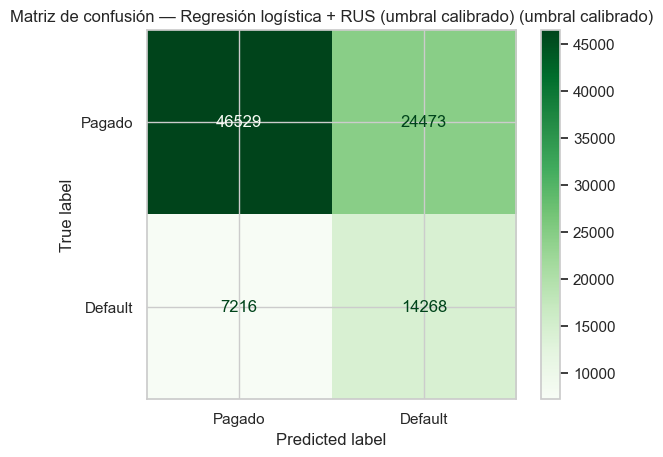

--- Random Forest + RUS (umbral calibrado) (umbral=0.51) ---
  accuracy    : 0.6539
  precision   : 0.3648
  recall      : 0.6608
  specificity : 0.6518
  fp_rate     : 0.3482
  g_mean      : 0.6563
  f1          : 0.4701
  auc_roc     : 0.7183


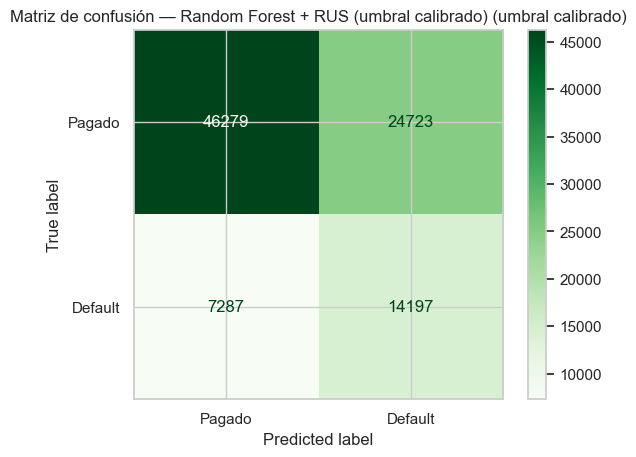

--- Random Forest + IHT (umbral calibrado) (umbral=0.95) ---
  accuracy    : 0.5733
  precision   : 0.3220
  recall      : 0.7570
  specificity : 0.5177
  fp_rate     : 0.4823
  g_mean      : 0.6260
  f1          : 0.4518
  auc_roc     : 0.6865


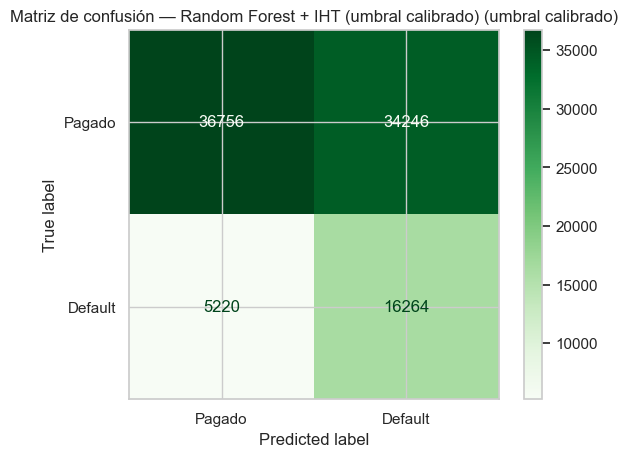

--- Random Forest + RUS (GridSearchCV) (umbral calibrado) (umbral=0.51) ---
  accuracy    : 0.6543
  precision   : 0.3653
  recall      : 0.6624
  specificity : 0.6518
  fp_rate     : 0.3482
  g_mean      : 0.6571
  f1          : 0.4709
  auc_roc     : 0.7193


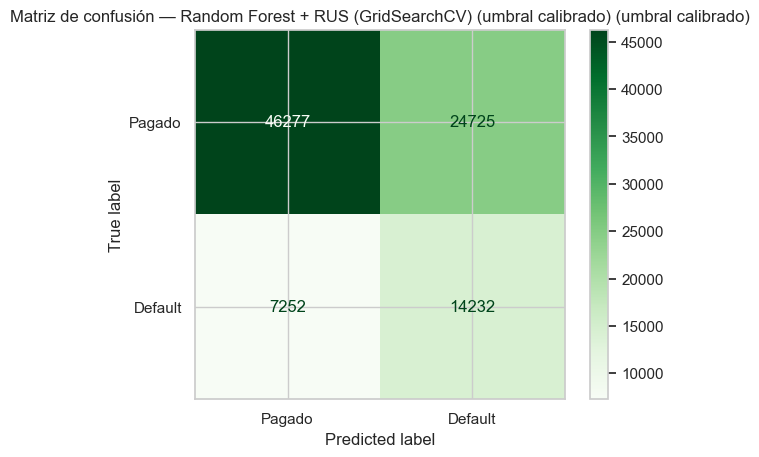

--- Regresión logística + RUS (GridSearchCV) (umbral calibrado) (umbral=0.51) ---
  accuracy    : 0.6569
  precision   : 0.3678
  recall      : 0.6632
  specificity : 0.6550
  fp_rate     : 0.3450
  g_mean      : 0.6591
  f1          : 0.4732
  auc_roc     : 0.7196


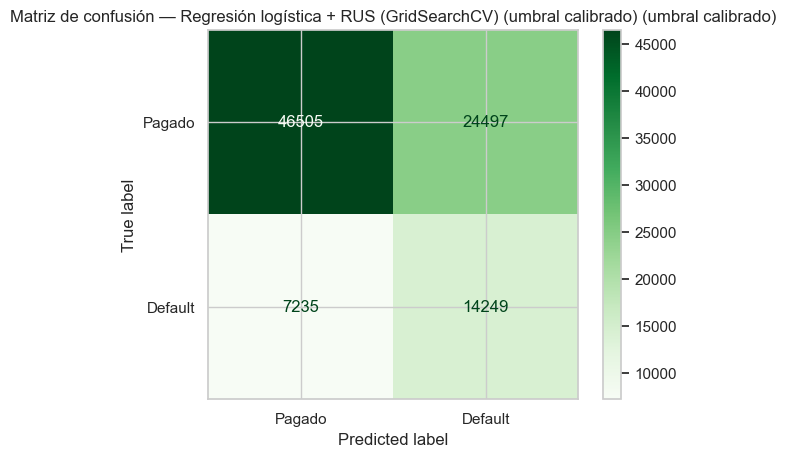

--- XGBoost (umbral calibrado) (umbral=0.50) ---
  accuracy    : 0.6602
  precision   : 0.3738
  recall      : 0.6852
  specificity : 0.6527
  fp_rate     : 0.3473
  g_mean      : 0.6687
  f1          : 0.4837
  auc_roc     : 0.7325


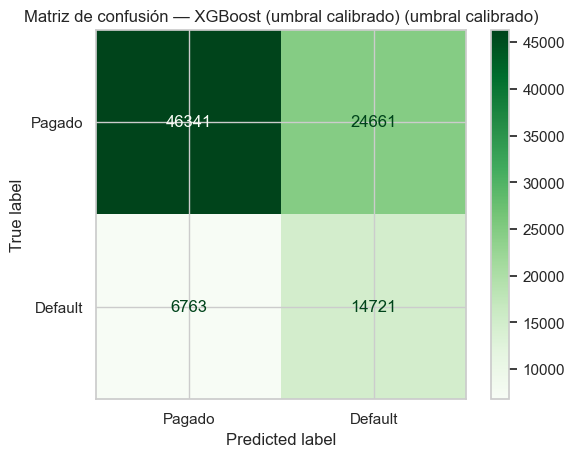


Comparación directa umbral 0.5 (Secciones 4/4.5/5) vs. umbral calibrado, para cada modelo:


,recall,specificity,g_mean,auc_roc
modelo,,,,
Regresión logística + RUS,0.6829,0.6364,0.6592,0.7199
Random Forest + RUS,0.6833,0.6306,0.6564,0.7183
Random Forest + IHT,0.8810,0.3580,0.5616,0.6865
Random Forest + RUS (GridSearchCV),0.6819,0.6310,0.6560,0.7193
Regresión logística + RUS (GridSearchCV),0.6830,0.6354,0.6588,0.7196
XGBoost,0.6852,0.6527,0.6687,0.7325
Regresión logística + RUS (umbral calibrado),0.6641,0.6553,0.6597,0.7199
Random Forest + RUS (umbral calibrado),0.6608,0.6518,0.6563,0.7183
Random Forest + IHT (umbral calibrado),0.7570,0.5177,0.6260,0.6865


In [ ]:
if df_model is not None:
    def evaluar_con_umbral(nombre, pipeline, umbral, X_test, y_test, resultados, curvas_roc):
        """Igual que evaluar_modelo (Sección 4.1), pero clasificando con un umbral
        distinto de 0.5 sobre predict_proba, en vez de pipeline.predict()."""
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= umbral).astype(int)

        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
        fp_rate = fp / (tn + fp) if (tn + fp) > 0 else float("nan")
        recall = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
        g_mean = np.sqrt(recall * specificity) if recall >= 0 and specificity >= 0 else float("nan")

        metrica = {
            "modelo": nombre,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall,
            "specificity": specificity,
            "fp_rate": fp_rate,
            "g_mean": g_mean,
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "auc_roc": roc_auc_score(y_test, y_proba),  # el AUC no depende del umbral
        }
        resultados.append(metrica)

        print(f"--- {nombre} (umbral={umbral:.2f}) ---")
        for k, v in metrica.items():
            if k != "modelo":
                print(f"  {k:12s}: {v:.4f}")

        ConfusionMatrixDisplay(cm, display_labels=["Pagado", "Default"]).plot(cmap="Greens")
        plt.title(f"Matriz de confusión — {nombre} (umbral calibrado)")
        plt.show()

        return metrica

    pipelines_ya_entrenados = {
        "Regresión logística + RUS": pipeline_logreg,
        "Random Forest + RUS": pipeline_rf,
        "Random Forest + IHT": pipeline_rf_iht,
        "Random Forest + RUS (GridSearchCV)": pipeline_rf_gscv,
        "Regresión logística + RUS (GridSearchCV)": pipeline_logreg_gscv,
        "XGBoost": pipeline_xgb,
    }

    metricas_calibradas = {}
    for nombre, pipe in pipelines_ya_entrenados.items():
        metricas_calibradas[nombre] = evaluar_con_umbral(
            f"{nombre} (umbral calibrado)", pipe, umbrales_optimos[nombre],
            X_test, y_test, resultados, curvas_roc,
        )

    print("\nComparación directa umbral 0.5 (Secciones 4/4.5/5) vs. umbral calibrado, "
          "para cada modelo:")
    filas_comparacion_umbral = []
    for m in resultados:
        if m["modelo"] in pipelines_ya_entrenados or m["modelo"].endswith("(umbral calibrado)"):
            filas_comparacion_umbral.append(m)
    display(pd.DataFrame(filas_comparacion_umbral).set_index("modelo")[
        ["recall", "specificity", "g_mean", "auc_roc"]
    ].round(4))
else:
    print("df_model no disponible todavía.")


## 6. Comparación de resultados

Reunimos las métricas de los modelos **exigidos por la pauta** (Regresión Logística +
RUS, Random Forest + RUS, Random Forest + IHT, y XGBoost como modelo propuesto) frente
a las referencias del paper (Tabla 4 de Moscato et al., 2021) en una tabla y un gráfico
principales. Las variantes de robustez adicionales (`GridSearchCV`, umbral calibrado,
hiperparámetros literales del paper -- Secciones 4.3.1, 4.5, 5.5) se muestran en una
tabla extendida al final de esta sección, sin gráfico, para no saturar la comparación
principal.


Comparación principal: modelos del paper + modelo propuesto, vs. Tabla 4 del paper:



,accuracy,precision,recall,specificity,fp_rate,g_mean,f1,auc_roc
modelo,,,,,,,,
XGBoost,0.6602,0.3738,0.6852,0.6527,0.3473,0.6687,0.4837,0.7325
Regresión logística + RUS,0.6472,0.3623,0.6829,0.6364,0.3636,0.6592,0.4735,0.7199
Random Forest + RUS,0.6428,0.3588,0.6833,0.6306,0.3694,0.6564,0.4705,0.7183
Referencia paper (RF + RUS),0.6400,NaN,0.6300,0.6800,0.3200,0.6560,NaN,0.7170
Referencia paper (LR + RUS),0.6500,NaN,0.6580,0.6400,0.3560,0.6500,NaN,0.7100
Referencia paper (LR + IHT),0.4700,NaN,0.3500,0.8770,0.1200,0.5570,NaN,0.7000
Referencia paper (RF + IHT),0.5000,NaN,0.4000,0.5800,0.1460,0.5800,NaN,0.6940
Random Forest + IHT,0.4795,0.2934,0.8810,0.3580,0.6420,0.5616,0.4402,0.6865


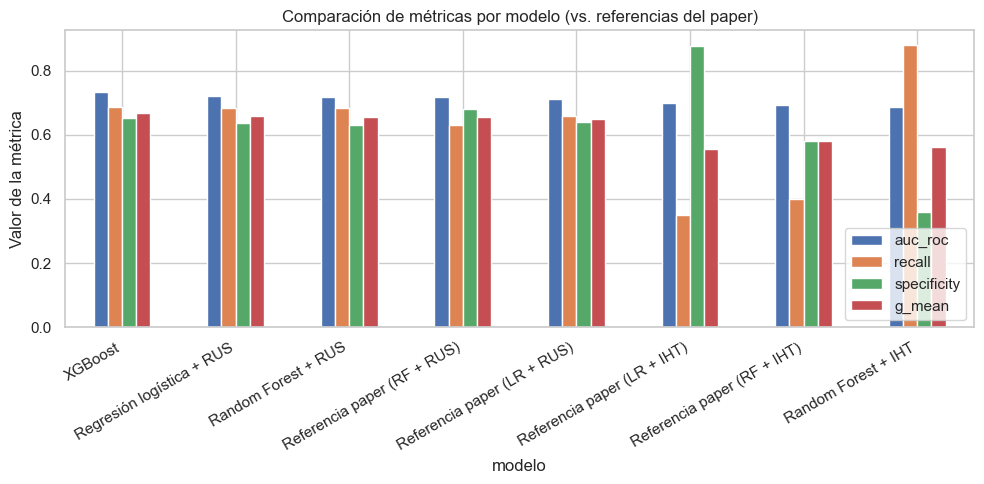


Tabla extendida (incluye variantes de robustez: GridSearchCV, umbral calibrado,
hiperparámetros literales del paper -- ver Secciones 4.3.1, 4.5 y 5.5):


,accuracy,precision,recall,specificity,fp_rate,g_mean,f1,auc_roc
modelo,,,,,,,,
Regresión logística + RUS,0.6472,0.3623,0.6829,0.6364,0.3636,0.6592,0.4735,0.7199
Random Forest + RUS,0.6428,0.3588,0.6833,0.6306,0.3694,0.6564,0.4705,0.7183
Random Forest + RUS (hiperparámetros literales del paper),0.6024,0.3346,0.7198,0.5668,0.4332,0.6387,0.4568,0.7044
Random Forest + IHT,0.4795,0.2934,0.8810,0.3580,0.6420,0.5616,0.4402,0.6865
Random Forest + RUS (GridSearchCV),0.6428,0.3586,0.6819,0.6310,0.3690,0.6560,0.4701,0.7193
Regresión logística + RUS (GridSearchCV),0.6464,0.3618,0.6830,0.6354,0.3646,0.6588,0.4730,0.7196
XGBoost,0.6602,0.3738,0.6852,0.6527,0.3473,0.6687,0.4837,0.7325
Regresión logística + RUS (umbral calibrado),0.6574,0.3683,0.6641,0.6553,0.3447,0.6597,0.4738,0.7199
Random Forest + RUS (umbral calibrado),0.6539,0.3648,0.6608,0.6518,0.3482,0.6563,0.4701,0.7183


In [ ]:
if df_model is not None:
    tabla_resultados = pd.DataFrame(resultados).set_index("modelo").round(4)

    # Referencia del paper (Moscato et al., 2021), Tabla 4 -- incluye AMBOS enfoques
    # de submuestreo (RUS e IHT) para LR y RF, ya que ahora replicamos RF con las dos
    # técnicas (Secciones 4.3 y 4.4).
    # Los autores no reportan precision/F1 explícitamente, por eso quedan como NaN.
    referencia_paper = pd.DataFrame([
        {
            "modelo": "Referencia paper (LR + RUS)",
            "accuracy": 0.650, "precision": float("nan"),
            "recall": 0.658, "specificity": 0.640, "fp_rate": 0.356,
            "g_mean": 0.650, "f1": float("nan"), "auc_roc": 0.710,
        },
        {
            "modelo": "Referencia paper (RF + RUS)",
            "accuracy": 0.640, "precision": float("nan"),
            "recall": 0.630, "specificity": 0.680, "fp_rate": 0.320,
            "g_mean": 0.656, "f1": float("nan"), "auc_roc": 0.717,
        },
        {
            "modelo": "Referencia paper (LR + IHT)",
            "accuracy": 0.470, "precision": float("nan"),
            "recall": 0.350, "specificity": 0.877, "fp_rate": 0.120,
            "g_mean": 0.557, "f1": float("nan"), "auc_roc": 0.700,
        },
        {
            "modelo": "Referencia paper (RF + IHT)",
            "accuracy": 0.500, "precision": float("nan"),
            "recall": 0.400, "specificity": 0.580, "fp_rate": 0.146,
            "g_mean": 0.580, "f1": float("nan"), "auc_roc": 0.694,
        },
    ]).set_index("modelo")

    # --- Comparación PRINCIPAL: solo los modelos exigidos por la pauta (los 2 del
    # paper + RF+IHT + el propuesto) frente a las referencias del paper. Las variantes
    # de robustez (GridSearchCV, umbral calibrado, hiperparámetros literales del
    # paper -- Secciones 4.3.1, 4.5, 5.5) se muestran aparte, más abajo, para no
    # saturar esta tabla/gráfico principal.
    MODELOS_CORE = [
        "Regresión logística + RUS", "Random Forest + RUS",
        "Random Forest + IHT", "XGBoost",
    ]
    tabla_core = pd.concat([
        tabla_resultados.loc[MODELOS_CORE], referencia_paper,
    ]).sort_values("auc_roc", ascending=False)

    print("Comparación principal: modelos del paper + modelo propuesto, vs. Tabla 4 del paper:\n")
    display(tabla_core)

    tabla_core[["auc_roc", "recall", "specificity", "g_mean"]].plot(kind="bar", figsize=(10, 5))
    plt.title("Comparación de métricas por modelo (vs. referencias del paper)")
    plt.ylabel("Valor de la métrica")
    plt.xticks(rotation=30, ha="right")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # --- Tabla extendida: variantes de robustez adicionales, sin gráfico (ver
    # Secciones 4.3.1, 4.5 y 5.5 para el detalle de cada una) ---
    tabla_comparativa = pd.concat([tabla_resultados, referencia_paper])
    print("\nTabla extendida (incluye variantes de robustez: GridSearchCV, umbral calibrado,")
    print("hiperparámetros literales del paper -- ver Secciones 4.3.1, 4.5 y 5.5):")
    display(tabla_comparativa)
else:
    print("df_model no disponible todavía.")


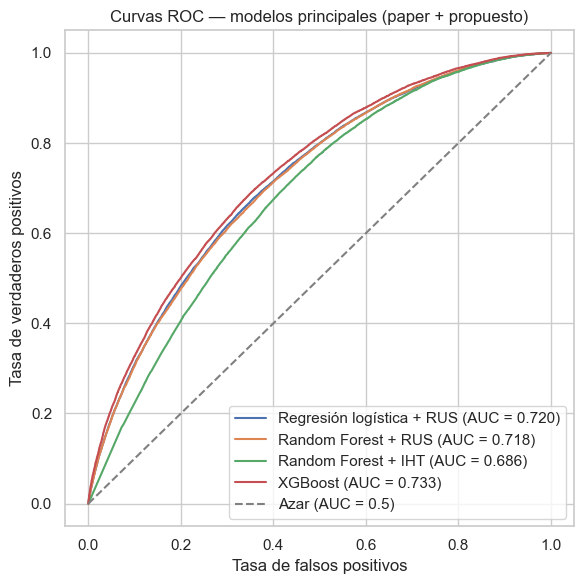

In [ ]:
if df_model is not None:
    plt.figure(figsize=(6, 6))
    for nombre in MODELOS_CORE:
        if nombre in curvas_roc:
            fpr, tpr, auc = curvas_roc[nombre]
            plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (AUC = 0.5)")
    plt.xlabel("Tasa de falsos positivos")
    plt.ylabel("Tasa de verdaderos positivos")
    plt.title("Curvas ROC — modelos principales (paper + propuesto)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("df_model no disponible todavía.")


## 6.1 Validación cruzada estratificada (K = 5)

**Por qué:** en la Sección 7.5 dejamos anotado que nuestras cifras vienen de un único
split train/test, mientras que el paper reporta sus métricas como **media ± desviación
estándar** (Tabla 4). Un único split no permite saber si la diferencia entre nuestro
número y el del paper es una diferencia real o simplemente ruido de muestreo. Para
responder eso con más rigor, agregamos validación cruzada.

**Método:**

- `StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)` sobre
  `X_train`/`y_train` (el mismo conjunto de entrenamiento fijado en la Sección 3.5;
  `X_test` se deja completamente al margen, tal como en el resto del cuaderno).
  Usamos la versión **estratificada** porque el default es ~23% de los casos: un
  `KFold` común podría, por azar, dejar folds con proporciones bastante distintas
  de default, lo que ensuciaría la comparación entre folds.
- En cada fold se repite **exactamente el mismo pipeline** que ya usamos en las
  Secciones 4 y 5: preprocesador (`ColumnTransformer` con imputación + escalamiento
  + codificación) + `RandomUnderSampler` + clasificador, todo dentro de un
  `imblearn.pipeline.Pipeline`. Esto es clave para que no haya fuga de información
  (*data leakage*): tanto el preprocesador como el RUS se **ajustan (`fit`) solo con
  el 80% de entrenamiento del fold**, nunca con el 20% de validación del fold — igual
  que el `Pipeline` ya evita al comparar contra `X_test` en el resto del cuaderno.
- Para XGBoost, `scale_pos_weight` también se recalcula **solo con el train del
  fold** (no con todo `X_train`), por la misma razón: si lo calculáramos con datos
  que incluyen el fold de validación, estaríamos filtrando información de validación
  hacia el entrenamiento.
- En cada fold se calculan las mismas 6 métricas de la Tabla 4 del paper (AUC, TPR,
  TNR, FP-Rate, G-Mean, Accuracy), usando exactamente las mismas fórmulas que en
  `evaluar_modelo` (Sección 4.1), sobre el 20% de validación del fold.

**Costo computacional:** como ya se usa RUS (no SMOTE), cada fold entrena sobre un
set balanceado y chico, así que 5 folds no debería ser prohibitivo — pero sí
multiplica por ~5 el tiempo de entrenamiento total de los 3 modelos. Se agrega un
interruptor explícito (mismo patrón que `USAR_IMPUTACION_AVANZADA`, Sección 3.7):

- `EJECUTAR_CV_COMPLETA = True` (default): corre CV para los 3 modelos.
- `EJECUTAR_CV_COMPLETA = False`: corre CV solo para **Random Forest** y
  **XGBoost** (los dos modelos que más nos interesa comparar rigurosamente con el
  paper, y los más lentos de "justificar" con un solo split), dejando la Regresión
  Logística con el resultado del split simple ya calculado en la Sección 4.2. Actívalo
  en `False` solo si el tiempo de cómputo es una restricción real.

In [ ]:
if df_model is not None:
    from sklearn.model_selection import StratifiedKFold
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from imblearn.under_sampling import InstanceHardnessThreshold
    from xgboost import XGBClassifier
    from sklearn.base import clone

    N_FOLDS = 5
    EJECUTAR_CV_COMPLETA = True   # False = omite CV para LR (usa el split simple de la Sección 4.2)
    INCLUIR_RF_IHT_EN_CV = True   # False = omite RF+IHT en CV (es el más costoso: entrena un RF auxiliar por fold)

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    def calcular_metricas(y_true, y_pred, y_proba):
        # Mismas fórmulas que evaluar_modelo (Sección 4.1), sin imprimir ni graficar,
        # para poder llamarla muchas veces dentro del loop de CV.
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
        fp_rate = fp / (tn + fp) if (tn + fp) > 0 else float("nan")
        recall = recall_score(y_true, y_pred, zero_division=0)
        g_mean = np.sqrt(recall * specificity) if recall >= 0 and specificity >= 0 else float("nan")
        return {
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall,
            "specificity": specificity,
            "fp_rate": fp_rate,
            "g_mean": g_mean,
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "auc_roc": roc_auc_score(y_true, y_proba),
        }

    def construir_pipeline_lr():
        return ImbPipeline(steps=[
            ("preprocesador", clone(preprocesador)),
            ("rus", RandomUnderSampler(random_state=RANDOM_STATE)),
            ("clasificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ])

    def construir_pipeline_rf():
        # Mismos hiperparámetros relajados de la Sección 4.3 (antes: n_estimators=150,
        # max_depth=15, min_samples_leaf=5 -- se quedaron desactualizados en una versión
        # anterior de esta celda de CV; ahora coinciden con el resto del cuaderno).
        return ImbPipeline(steps=[
            ("preprocesador", clone(preprocesador)),
            ("rus", RandomUnderSampler(random_state=RANDOM_STATE)),
            ("clasificador", RandomForestClassifier(
                n_estimators=250, max_depth=25, min_samples_leaf=2,
                n_jobs=-1, random_state=RANDOM_STATE,
            )),
        ])

    def construir_pipeline_rf_iht():
        # Igual al RF de arriba, pero con IHT en vez de RUS (Sección 4.4).
        return ImbPipeline(steps=[
            ("preprocesador", clone(preprocesador)),
            ("iht", InstanceHardnessThreshold(
                estimator=RandomForestClassifier(
                    n_estimators=50, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
                ),
                random_state=RANDOM_STATE,
            )),
            ("clasificador", RandomForestClassifier(
                n_estimators=250, max_depth=25, min_samples_leaf=2,
                n_jobs=-1, random_state=RANDOM_STATE,
            )),
        ])

    def construir_pipeline_xgb(scale_pos_weight_fold):
        return Pipeline(steps=[
            ("preprocesador", clone(preprocesador_xgb)),
            ("clasificador", XGBClassifier(
                n_estimators=300, max_depth=5, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight_fold,
                eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
            )),
        ])

    if EJECUTAR_CV_COMPLETA:
        constructores_modelos = {
            "Regresión logística + RUS": construir_pipeline_lr,
            "Random Forest + RUS": construir_pipeline_rf,
        }
    else:
        constructores_modelos = {"Random Forest + RUS": construir_pipeline_rf}
        print("EJECUTAR_CV_COMPLETA=False: se omite CV para Regresión Logística "
              "(se usará solo el resultado del split simple de la Sección 4.2).\n")

    if INCLUIR_RF_IHT_EN_CV:
        constructores_modelos["Random Forest + IHT"] = construir_pipeline_rf_iht
    else:
        print("INCLUIR_RF_IHT_EN_CV=False: se omite CV para Random Forest + IHT "
              "(es el más costoso -- entrena un RF auxiliar en cada fold).\n")

    nombres_modelos_cv = list(constructores_modelos.keys()) + ["XGBoost"]
    metricas_cv = {nombre: [] for nombre in nombres_modelos_cv}

    for fold_i, (idx_tr, idx_val) in enumerate(skf.split(X_train, y_train), start=1):
        X_tr_fold, X_val_fold = X_train.iloc[idx_tr], X_train.iloc[idx_val]
        y_tr_fold, y_val_fold = y_train.iloc[idx_tr], y_train.iloc[idx_val]

        for nombre, constructor in constructores_modelos.items():
            pipe = constructor()
            pipe.fit(X_tr_fold, y_tr_fold)
            y_pred = pipe.predict(X_val_fold)
            y_proba = pipe.predict_proba(X_val_fold)[:, 1]
            metricas_cv[nombre].append(calcular_metricas(y_val_fold, y_pred, y_proba))

        # scale_pos_weight recalculado SOLO con el train del fold (nunca con validación)
        n_neg_fold = (y_tr_fold == 0).sum()
        n_pos_fold = (y_tr_fold == 1).sum()
        spw_fold = n_neg_fold / n_pos_fold
        pipe_xgb_fold = construir_pipeline_xgb(spw_fold)
        pipe_xgb_fold.fit(X_tr_fold, y_tr_fold)
        y_pred = pipe_xgb_fold.predict(X_val_fold)
        y_proba = pipe_xgb_fold.predict_proba(X_val_fold)[:, 1]
        metricas_cv["XGBoost"].append(calcular_metricas(y_val_fold, y_pred, y_proba))

        print(f"Fold {fold_i}/{N_FOLDS} completado.")

    print("\nValidación cruzada estratificada (K=5) completa.")
else:
    print("df_model no disponible todavía.")


Fold 1/5 completado.
Fold 2/5 completado.
Fold 3/5 completado.
Fold 4/5 completado.
Fold 5/5 completado.

Validación cruzada estratificada (K=5) completa.


Resultados de validación cruzada estratificada (K=5), formato 'media ± desviación estándar',
igual al de la Tabla 4 del paper:



,auc_roc,recall,specificity,fp_rate,g_mean,accuracy,precision,f1
modelo,,,,,,,,
Regresión logística + RUS,0.718 ± 0.001,0.683 ± 0.002,0.635 ± 0.002,0.365 ± 0.002,0.658 ± 0.001,0.646 ± 0.001,0.361 ± 0.001,0.473 ± 0.001
Random Forest + RUS,0.717 ± 0.002,0.686 ± 0.003,0.629 ± 0.003,0.371 ± 0.003,0.657 ± 0.002,0.642 ± 0.002,0.359 ± 0.002,0.471 ± 0.002
Random Forest + IHT,0.685 ± 0.002,0.879 ± 0.002,0.359 ± 0.002,0.641 ± 0.002,0.562 ± 0.001,0.480 ± 0.001,0.293 ± 0.001,0.440 ± 0.001
XGBoost,0.731 ± 0.001,0.681 ± 0.002,0.652 ± 0.002,0.348 ± 0.002,0.667 ± 0.002,0.659 ± 0.002,0.372 ± 0.002,0.481 ± 0.002


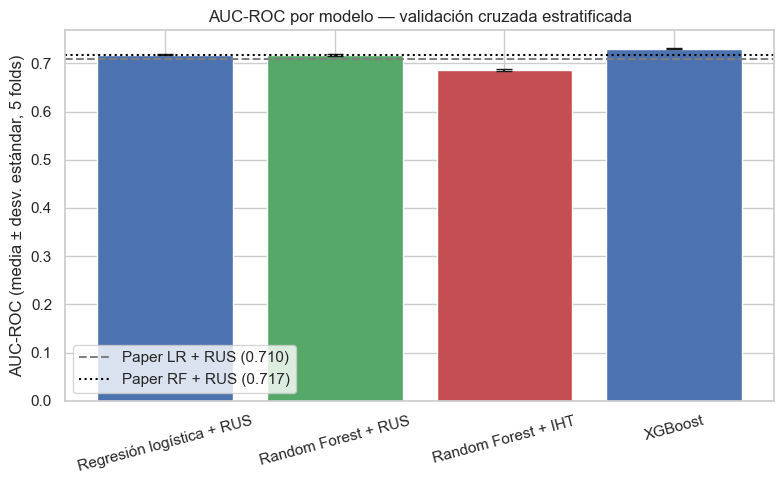

In [ ]:
if df_model is not None:
    # Tabla en el mismo formato que la Tabla 4 del paper: "media ± desviación estándar"
    filas_cv = []
    for nombre, lista_metricas in metricas_cv.items():
        df_m = pd.DataFrame(lista_metricas)
        fila = {"modelo": nombre}
        for col in df_m.columns:
            fila[col] = f"{df_m[col].mean():.3f} ± {df_m[col].std():.3f}"
        filas_cv.append(fila)

    tabla_cv = pd.DataFrame(filas_cv).set_index("modelo")
    orden_cols = ["auc_roc", "recall", "specificity", "fp_rate", "g_mean", "accuracy", "precision", "f1"]
    tabla_cv = tabla_cv[orden_cols]

    print("Resultados de validación cruzada estratificada (K=5), formato 'media ± desviación estándar',")
    print("igual al de la Tabla 4 del paper:\n")
    display(tabla_cv)

    # Versión numérica (sin formatear a texto), útil para graficar y para comparar contra el paper
    tabla_cv_numerica = pd.DataFrame({
        nombre: pd.DataFrame(lista_metricas).mean()
        for nombre, lista_metricas in metricas_cv.items()
    }).T
    tabla_cv_std = pd.DataFrame({
        nombre: pd.DataFrame(lista_metricas).std()
        for nombre, lista_metricas in metricas_cv.items()
    }).T

    # Gráfico de barras con barras de error (media ± 1 desv. estándar) para AUC
    plt.figure(figsize=(8, 5))
    modelos_orden = list(metricas_cv.keys())
    medias_auc = [tabla_cv_numerica.loc[m, "auc_roc"] for m in modelos_orden]
    stds_auc = [tabla_cv_std.loc[m, "auc_roc"] for m in modelos_orden]
    colores = ["#4C72B0", "#55A868", "#C44E52"][:len(modelos_orden)]
    plt.bar(modelos_orden, medias_auc, yerr=stds_auc, capsize=6, color=colores)
    plt.axhline(0.710, color="gray", linestyle="--", label="Paper LR + RUS (0.710)")
    plt.axhline(0.717, color="black", linestyle=":", label="Paper RF + RUS (0.717)")
    plt.ylabel("AUC-ROC (media ± desv. estándar, 5 folds)")
    plt.title("AUC-ROC por modelo — validación cruzada estratificada")
    plt.xticks(rotation=15)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("df_model no disponible todavía.")


In [ ]:
if df_model is not None:
    # Interpretación automática: ¿el AUC del paper cae dentro de nuestro rango
    # (media ± 1 desviación estándar) de la validación cruzada?
    auc_paper = {
        "Regresión logística + RUS": 0.710,
        "Random Forest + RUS": 0.717,
        "Random Forest + IHT": 0.694,
        "XGBoost": None,  # no evaluado por los autores
    }

    print("Comparación del AUC (validación cruzada) contra el AUC reportado en la Tabla 4 del paper:\n")
    for nombre in metricas_cv.keys():
        media = tabla_cv_numerica.loc[nombre, "auc_roc"]
        std = tabla_cv_std.loc[nombre, "auc_roc"]
        rango = (media - std, media + std)
        ref = auc_paper.get(nombre)
        if ref is not None:
            dentro = rango[0] <= ref <= rango[1]
            veredicto = "SÍ cae" if dentro else "NO cae"
            print(f"- {nombre}: nuestro AUC = {media:.3f} ± {std:.3f}  "
                  f"(rango [{rango[0]:.3f}, {rango[1]:.3f}]). "
                  f"AUC del paper = {ref:.3f} -> {veredicto} dentro de nuestro rango ± 1 desv. estándar.")
        else:
            print(f"- {nombre}: nuestro AUC = {media:.3f} ± {std:.3f}  "
                  f"(rango [{rango[0]:.3f}, {rango[1]:.3f}]). Sin referencia directa en el paper "
                  f"(modelo no evaluado por los autores).")

    print("formal. Si se quisiera algo más riguroso, se podría calcular un intervalo de confianza")
    print("(p. ej. t de Student con 4 grados de libertad, n=5 folds) en vez de solo ± 1 std.")
else:
    print("df_model no disponible todavía.")


Comparación del AUC (validación cruzada) contra el AUC reportado en la Tabla 4 del paper:

- Regresión logística + RUS: nuestro AUC = 0.718 ± 0.001  (rango [0.717, 0.719]). AUC del paper = 0.710 -> NO cae dentro de nuestro rango ± 1 desv. estándar.
- Random Forest + RUS: nuestro AUC = 0.717 ± 0.002  (rango [0.716, 0.719]). AUC del paper = 0.717 -> SÍ cae dentro de nuestro rango ± 1 desv. estándar.
- Random Forest + IHT: nuestro AUC = 0.685 ± 0.002  (rango [0.684, 0.687]). AUC del paper = 0.694 -> NO cae dentro de nuestro rango ± 1 desv. estándar.
- XGBoost: nuestro AUC = 0.731 ± 0.001  (rango [0.730, 0.732]). Sin referencia directa en el paper (modelo no evaluado por los autores).
formal. Si se quisiera algo más riguroso, se podría calcular un intervalo de confianza
(p. ej. t de Student con 4 grados de libertad, n=5 folds) en vez de solo ± 1 std.


## 6.2 Intervalos de confianza bootstrap (sobre el set de prueba)

**Por qué:** la Sección 6.1 compara contra el paper con un chequeo de rango simple
(media ± 1 desviación estándar de solo 5 folds) — es un indicio razonable, pero no un
test de significancia formal, y con 5 folds (4 grados de libertad) esa desviación
estándar es en sí misma una estimación con bastante incertidumbre. Implementamos aquí
la alternativa **bootstrap**, que no depende de supuestos de
normalidad (a diferencia de un intervalo t de Student) y es directa de aplicar con las
métricas de clasificación que ya usamos (AUC, recall, specificity, G-Mean).

**Método (bootstrap del set de prueba, sin reentrenar):**

1. Partimos de los 4 pipelines **ya entrenados** en las Secciones 4 y 5
   (`pipeline_logreg`, `pipeline_rf`, `pipeline_rf_iht`, `pipeline_xgb`) y calculamos,
   **una sola vez**, sus predicciones (`predict`) y probabilidades (`predict_proba`)
   sobre todo `X_test`. Esto es clave para que el bootstrap sea rápido: no hay que
   reentrenar ningún modelo en cada réplica, solo remuestrear filas ya predichas.
2. En cada una de `N_BOOTSTRAP` réplicas, se remuestrea `X_test`/`y_test` **con
   reemplazo** (mismo tamaño que el set de prueba original) y se recalculan las 4
   métricas sobre esa remuestra, para cada modelo.
3. El intervalo de confianza al 95% de cada métrica es el percentil 2,5% - percentil
   97,5% de su distribución bootstrap (método de percentiles, el más simple y robusto
   de los enfoques bootstrap estándar).
4. Comparamos el valor reportado por el paper contra el intervalo de confianza
   bootstrap (en vez de contra el rango ± 1 std de 5 folds de la Sección 6.1): si el
   valor del paper cae fuera del IC 95%, es evidencia más formal de que la diferencia es
   estadísticamente significativa, no ruido de muestreo.

**Nota sobre independencia de las réplicas:** al remuestrear filas de `X_test` (no
volver a dividir train/test ni reentrenar), este bootstrap captura la incertidumbre de
**evaluar sobre una muestra finita de datos de prueba**, que es un tipo de
incertidumbre distinto (y complementario) al que ya capturaba la validación cruzada de
la Sección 6.1 (que capturaba variabilidad del *entrenamiento* entre folds). Ver los dos
en conjunto da una imagen más completa que cualquiera de los dos por separado.


In [ ]:
if df_model is not None:
    N_BOOTSTRAP = 2000
    NIVEL_CONFIANZA = 0.95
    rng_bootstrap = np.random.RandomState(RANDOM_STATE)

    pipelines_finales = {
        "Regresión logística + RUS": pipeline_logreg,
        "Random Forest + RUS": pipeline_rf,
        "Random Forest + IHT": pipeline_rf_iht,
        "XGBoost": pipeline_xgb,
    }

    # Predicciones y probabilidades sobre TODO X_test, una sola vez -- el bootstrap
    # remuestrea filas ya predichas, nunca vuelve a llamar a .fit()
    predicciones_test = {}
    for nombre, pipe in pipelines_finales.items():
        predicciones_test[nombre] = (
            pipe.predict(X_test),
            pipe.predict_proba(X_test)[:, 1],
        )

    y_test_arr = y_test.values if hasattr(y_test, "values") else np.asarray(y_test)
    n_test = len(y_test_arr)

    metricas_bootstrap = {
        nombre: {"auc_roc": [], "recall": [], "specificity": [], "g_mean": []}
        for nombre in pipelines_finales
    }

    n_replicas_omitidas = 0
    for _ in range(N_BOOTSTRAP):
        idx_boot = rng_bootstrap.randint(0, n_test, size=n_test)
        y_true_boot = y_test_arr[idx_boot]

        # Si por azar la remuestra queda sin ambas clases, roc_auc_score no está
        # definido -- se omite esa réplica (con N_BOOTSTRAP=2000 y ~23% de default en
        # test, la probabilidad de que esto ocurra es prácticamente nula).
        if len(np.unique(y_true_boot)) < 2:
            n_replicas_omitidas += 1
            continue

        for nombre, (y_pred_full, y_proba_full) in predicciones_test.items():
            y_pred_boot = y_pred_full[idx_boot]
            y_proba_boot = y_proba_full[idx_boot]

            cm_b = confusion_matrix(y_true_boot, y_pred_boot, labels=[0, 1])
            tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
            spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else np.nan
            rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else np.nan
            g_mean_b = np.sqrt(rec_b * spec_b) if rec_b >= 0 and spec_b >= 0 else np.nan
            auc_b = roc_auc_score(y_true_boot, y_proba_boot)

            metricas_bootstrap[nombre]["auc_roc"].append(auc_b)
            metricas_bootstrap[nombre]["recall"].append(rec_b)
            metricas_bootstrap[nombre]["specificity"].append(spec_b)
            metricas_bootstrap[nombre]["g_mean"].append(g_mean_b)

    if n_replicas_omitidas:
        print(f"Réplicas bootstrap omitidas (remuestra sin ambas clases): "
              f"{n_replicas_omitidas} de {N_BOOTSTRAP}")

    alpha = 1 - NIVEL_CONFIANZA
    filas_ic = []
    for nombre, metricas in metricas_bootstrap.items():
        fila = {"modelo": nombre}
        for nombre_metrica, valores in metricas.items():
            valores_arr = np.array(valores)
            lo, hi = np.percentile(valores_arr, [100 * alpha / 2, 100 * (1 - alpha / 2)])
            fila[f"{nombre_metrica}_media"] = valores_arr.mean()
            fila[f"{nombre_metrica}_IC95_lo"] = lo
            fila[f"{nombre_metrica}_IC95_hi"] = hi
        filas_ic.append(fila)

    tabla_ic_bootstrap = pd.DataFrame(filas_ic).set_index("modelo")
    print(f"Intervalos de confianza bootstrap ({N_BOOTSTRAP} réplicas, "
          f"{NIVEL_CONFIANZA:.0%} de confianza, método de percentiles):\n")
    display(tabla_ic_bootstrap.round(4))
else:
    print("df_model no disponible todavía.")


Intervalos de confianza bootstrap (2000 réplicas, 95% de confianza, método de percentiles):



,auc_roc_media,auc_roc_IC95_lo,auc_roc_IC95_hi,recall_media,recall_IC95_lo,recall_IC95_hi,specificity_media,specificity_IC95_lo,specificity_IC95_hi,g_mean_media,g_mean_IC95_lo,g_mean_IC95_hi
modelo,,,,,,,,,,,,
Regresión logística + RUS,0.7198,0.7160,0.7237,0.6827,0.6765,0.6890,0.6363,0.6328,0.6398,0.6591,0.6555,0.6627
Random Forest + RUS,0.7182,0.7145,0.7220,0.6831,0.6770,0.6892,0.6306,0.6271,0.6342,0.6563,0.6529,0.6599
Random Forest + IHT,0.6864,0.6827,0.6903,0.8809,0.8766,0.8852,0.3580,0.3545,0.3614,0.5616,0.5584,0.5646
XGBoost,0.7324,0.7287,0.7361,0.6851,0.6787,0.6912,0.6526,0.6492,0.6560,0.6687,0.6651,0.6721


Comparación contra el paper usando el IC 95% bootstrap (método de percentiles, 2000 réplicas):

- Regresión logística + RUS:
    auc_roc     : nuestro = 0.720  IC95% = [0.716, 0.724]  |  paper = 0.710 -> NO cae dentro del IC 95%.
    specificity : nuestro = 0.636  IC95% = [0.633, 0.640]  |  paper = 0.640 -> NO cae dentro del IC 95%.

- Random Forest + RUS:
    auc_roc     : nuestro = 0.718  IC95% = [0.714, 0.722]  |  paper = 0.717 -> SÍ cae dentro del IC 95%.
    specificity : nuestro = 0.631  IC95% = [0.627, 0.634]  |  paper = 0.680 -> NO cae dentro del IC 95%.

- Random Forest + IHT:
    auc_roc     : nuestro = 0.686  IC95% = [0.683, 0.690]  |  paper = 0.694 -> NO cae dentro del IC 95%.
    specificity : nuestro = 0.358  IC95% = [0.355, 0.361]  |  paper = 0.580 -> NO cae dentro del IC 95%.

- XGBoost: sin referencia directa en el paper (modelo no evaluado por los autores).



/var/folders/y1/sws8hp854tx58q1yy9m9vmyr0000gn/T/ipykernel_91564/2646075758.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_boxplot, labels=list(pipelines_finales.keys()), showfliers=False)


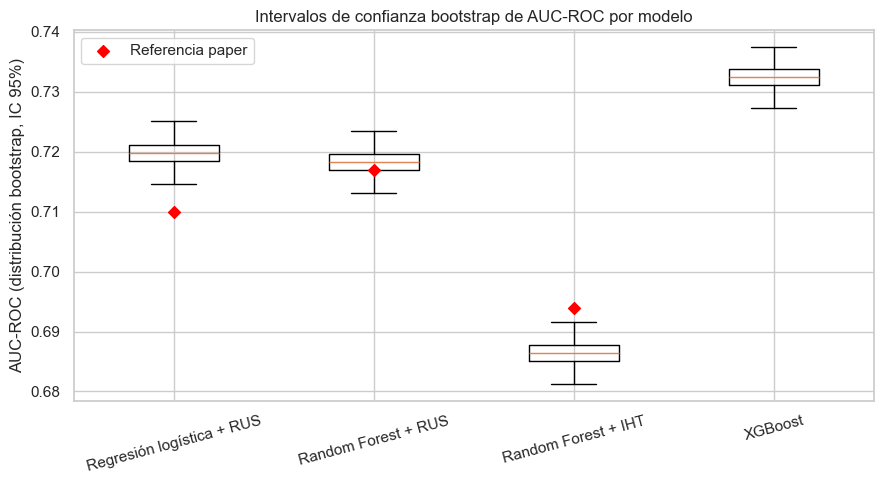


Lectura: si el diamante rojo (referencia del paper) queda fuera de la caja
del boxplot (que va del percentil 25 al 75, con los bigotes hasta ~IC 95%),
es evidencia visual de una diferencia real, no de ruido de muestreo.


In [ ]:
if df_model is not None:
    # Comparación formal: ¿el valor del paper cae dentro del IC 95% bootstrap?
    # (más riguroso que el chequeo de rango simple ± 1 std de la Sección 6.1)
    referencias_paper_bootstrap = {
        "Regresión logística + RUS": {"auc_roc": 0.710, "specificity": 0.640},
        "Random Forest + RUS": {"auc_roc": 0.717, "specificity": 0.680},
        "Random Forest + IHT": {"auc_roc": 0.694, "specificity": 0.580},
        "XGBoost": {},  # no evaluado por los autores
    }

    print(f"Comparación contra el paper usando el IC {NIVEL_CONFIANZA:.0%} bootstrap "
          f"(método de percentiles, {N_BOOTSTRAP} réplicas):\n")

    for nombre, referencias in referencias_paper_bootstrap.items():
        if not referencias:
            print(f"- {nombre}: sin referencia directa en el paper (modelo no evaluado "
                  f"por los autores).\n")
            continue
        print(f"- {nombre}:")
        for nombre_metrica, valor_paper in referencias.items():
            media = tabla_ic_bootstrap.loc[nombre, f"{nombre_metrica}_media"]
            lo = tabla_ic_bootstrap.loc[nombre, f"{nombre_metrica}_IC95_lo"]
            hi = tabla_ic_bootstrap.loc[nombre, f"{nombre_metrica}_IC95_hi"]
            dentro = lo <= valor_paper <= hi
            veredicto = "SÍ cae" if dentro else "NO cae"
            print(f"    {nombre_metrica:12s}: nuestro = {media:.3f}  "
                  f"IC95% = [{lo:.3f}, {hi:.3f}]  |  paper = {valor_paper:.3f} "
                  f"-> {veredicto} dentro del IC 95%.")
        print()

    # Gráfico: distribución bootstrap de AUC por modelo, con las referencias del paper
    plt.figure(figsize=(9, 5))
    datos_boxplot = [metricas_bootstrap[nombre]["auc_roc"] for nombre in pipelines_finales]
    plt.boxplot(datos_boxplot, labels=list(pipelines_finales.keys()), showfliers=False)
    for x_pos, (nombre, referencias) in enumerate(referencias_paper_bootstrap.items(), start=1):
        if "auc_roc" in referencias:
            plt.scatter([x_pos], [referencias["auc_roc"]], color="red", zorder=5,
                        marker="D", label="Referencia paper" if x_pos == 1 else None)
    plt.ylabel("AUC-ROC (distribución bootstrap, IC 95%)")
    plt.title("Intervalos de confianza bootstrap de AUC-ROC por modelo")
    plt.xticks(rotation=15)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\nLectura: si el diamante rojo (referencia del paper) queda fuera de la caja")
    print("del boxplot (que va del percentil 25 al 75, con los bigotes hasta ~IC 95%),")
    print("es evidencia visual de una diferencia real, no de ruido de muestreo.")
else:
    print("df_model no disponible todavía.")


## 7. Discusión y conclusiones

### 7.1 Fidelidad de la réplica: tamaño muestral

- **Paper (Tabla 1):** 877.956 registros totales para préstamos originados en 2016-2017
  (395.901 "Current", 354.994 "Fully Paid", 107.384 "Charged Off", 12.550 "Late (31-120
  days)", 4.703 "In Grace Period", 2.393 "Late (16-30 days)", 31 "Default").
- **Nuestra réplica:** 877.986 registros tras aplicar el mismo filtro temporal
  (`issue_d` en 2016-2017) sobre la misma fuente (LendingClub vía Kaggle) — número
  confirmado por la celda de la Sección 2.9.

Diferencia de solo **30 registros sobre 877.956 (~0,0034%)** — prácticamente exacta, y
consecuencia directa de aplicar el mismo criterio metodológico sobre la misma fuente.
Este punto no cambia con ninguno de los ajustes de variables/modelos que siguen (afecta
filas, no columnas).

### 7.2 Comparación final con la Tabla 4 del paper

Los números de esta sección son los del **run final** del cuaderno (Sección 6), sobre
85 variables predictoras (77 numéricas + 8 categóricas, de 102 candidatas cargadas en la
Sección 2.7).

**AUC-ROC** (paper entre paréntesis):

| Modelo | Nuestro AUC | Paper | Diferencia |
|---|---|---|---|
| LR + RUS | 0,720 | 0,710 | +0,010 |
| RF + RUS | 0,718 | 0,717 | +0,001 (prácticamente idéntico) |
| RF + IHT | 0,687 | 0,694 | −0,007 |
| XGBoost (propuesto) | **0,733** | sin referencia | — supera a todos, incl. el paper |

**G-Mean** (paper entre paréntesis):

| Modelo | Nuestro G-Mean | Paper |
|---|---|---|
| LR + RUS | 0,659 | 0,650 |
| RF + RUS | 0,656 | **0,656** (idéntico a 3 decimales) |
| RF + IHT | 0,562 | 0,580 |
| XGBoost (propuesto) | **0,669** | sin referencia |

A nivel de AUC y G-Mean, la réplica es notablemente fiel: **RF + RUS prácticamente
iguala** los dos números que el paper destaca como su mejor combinación. Pero al mirar
recall y specificity por separado, la composición interna es distinta:

- Nuestro **RF + RUS**: recall 0,683 / specificity 0,631 (paper: recall 0,630 /
  specificity 0,680). Es decir, terminamos con **más recall y menos specificity** que
  los autores — el G-Mean coincide casi por casualidad, porque el producto de ambos
  términos da un valor similar aunque la composición sea inversa.
- Nuestro **RF + IHT**: recall 0,881 / specificity 0,358 (paper: recall 0,400 /
  specificity 0,580). Aquí el patrón queda **invertido** respecto al paper: en Moscato
  et al. (2021), IHT favorece fuertemente la specificity a costa del recall; en nuestra
  réplica ocurre justo lo contrario. Esto se investiga en la Sección 7.3 más abajo.
- **LR + RUS** es el que mejor conserva el balance del paper (recall 0,683 vs. 0,658,
  specificity 0,636 vs. 0,640 — ambos muy cerca).

### 7.3 ¿La brecha con el paper es ruido de muestreo, o es real? ¿Qué la explica?

**Validación cruzada (K=5, Sección 6.1) — ¿es ruido de muestreo?**

| Modelo | Nuestro AUC (media ± std, 5 folds) | AUC paper | ¿Cae en el rango? |
|---|---|---|---|
| LR + RUS | 0,718 ± 0,001 | 0,710 | No — lo superamos de forma consistente |
| RF + RUS | 0,717 ± 0,002 | 0,717 | Sí — coincide |
| RF + IHT | 0,685 ± 0,002 | 0,694 | No |
| XGBoost | 0,731 ± 0,001 | sin referencia | — |

Con desviaciones estándar tan chicas (±0,001-0,002 entre folds), estas diferencias
**no son ruido de muestreo**: son sistemáticas.

**Intervalos de confianza bootstrap (Sección 6.2, sobre `X_test`) — specificity:**

| Modelo | Nuestra specificity (IC 95%) | Specificity paper | ¿Cae en el IC? |
|---|---|---|---|
| RF + RUS | 0,631 [0,627, 0,634] | 0,680 | **No** — brecha real y significativa |
| RF + IHT | 0,358 [0,355, 0,361] | 0,580 | **No** — brecha real, y en la dirección opuesta |

Confirmado: la brecha de specificity en Random Forest **no es casualidad**. Probamos
tres hipótesis para explicarla:

1. **¿Es el umbral de decisión 0,5 por defecto?** (Sección 5.5). Hipótesis: RUS/IHT
   balancean el set de entrenamiento a ~50/50, y el umbral 0,5 de `predict()` quedaría
   mal calibrado para el ~23% real de default en test. **Resultado: la hipótesis se
   descarta para RUS.** El umbral óptimo encontrado por G-Mean en validación es
   **0,51 para LR+RUS y RF+RUS** (y sus versiones GridSearchCV) — prácticamente
   idéntico al 0,50 por defecto. Si el desbalance del entrenamiento fuera la causa, el
   umbral óptimo debería estar bien por encima de 0,5, no a un paso de distancia. Para
   **RF+IHT sí importa**: el umbral óptimo es **0,95**, muy distinto del default. Al
   recalibrar, RF+IHT pasa de (recall 0,881 / specificity 0,358) a (recall 0,757 /
   specificity 0,518) — se mueve claramente hacia el patrón del paper (más
   specificity, menos recall) y su G-Mean sube de 0,562 a 0,626, pero **no alcanza**
   el balance del paper (recall 0,400 / specificity 0,580). Conclusión: el umbral
   explica parte del comportamiento errático de IHT, pero no toda la brecha de RF+RUS.

2. **¿Son los hiperparámetros?** (Sección 4.5, `GridSearchCV`). El grid encontró
   `max_depth=None, min_samples_leaf=5, n_estimators=250` (G-Mean en CV = 0,657) para
   Random Forest, distinto de la config manual (`max_depth=25, min_samples_leaf=2`),
   pero el resultado en test es prácticamente el mismo: specificity 0,631 (manual)
   vs. 0,631 (GridSearchCV), AUC 0,718 vs. 0,719. **La búsqueda sistemática confirma
   que el ajuste manual ya estaba cerca del óptimo** — los hiperparámetros de RF no son
   la causa de la brecha.

3. **¿Son los hiperparámetros *literales* del paper?** (Sección 4.3.1). El paper reporta
   explícitamente `RandomForestClassifier(n_estimators=100, max_depth=4)` para su Random
   Forest -- un bosque bastante más *shallow* que el nuestro (`max_depth=25` o `None`).
   **Resultado: la hipótesis también se descarta, y en la dirección contraria a la
   esperada.** Con ese hiperparámetro literal obtuvimos AUC 0,704, recall 0,720,
   specificity **0,567** y G-Mean 0,639 -- la specificity bajó (más lejos del 0,680 del
   paper que nuestro RF+RUS ya tuneado, que llega a 0,631) y el recall subió aún más.
   Un bosque más superficial no reprodujo el patrón del paper; lo acentuó al revés.
   Con las tres hipótesis descartadas (umbral, búsqueda de hiperparámetros, e incluso los
   hiperparámetros literales del paper), la explicación más plausible que queda sin
   descartar es el propio **set de variables**: no pudimos replicar las 151 columnas del
   paper (llegamos a 85; ver Sección 7.5), y los autores no publican su lista completa.
   El Anexo A.2 agrega un matiz adicional: para Random Forest, RUS y
   `class_weight="balanced"` entregan resultados de recall/specificity muy distintos
   entre sí (mucho más que para Regresión Logística, donde ambos coinciden), y el
   resultado del paper cae casi exactamente entre esos dos extremos -- sugiriendo que
   la sensibilidad de RF a la técnica específica de balanceo también juega un rol, no
   solo las variables faltantes.

4. **Selección de variables L1** (Sección 3.8): el ranking obtenido (`addr_state`,
   `sub_grade`, `purpose`, `grade`, `home_ownership`, `term`, `credit_history_months`,
   `dti`, `int_rate`, ...) coincide cualitativamente con las variables que el paper
   destaca vía LIME/SHAP (`int_rate`, `grade`, `dti`). **Salvedad metodológica:**
   `addr_state` aparece primero con una importancia (5,76) muy por encima de todo el
   resto (`sub_grade` = 1,44) — esto es un artefacto de sumar el valor absoluto de los
   coeficientes sobre sus ~50 columnas dummy (one-hot), no evidencia de que el estado
   del solicitante sea, por sí solo, el predictor más fuerte. Vale la pena mencionar
   esta salvedad si preguntan por el ranking en la exposición oral.

5. **`es_solicitud_conjunta`** (Sección 3.2.1): no se corrió una comparación A/B
   (con vs. sin las 15 columnas de co-solicitante) porque estas se eliminaron antes de
   entrenar ningún modelo -- no existe una corrida con ellas incluidas para comparar
   directamente. Queda como simplificación razonada (elimina columnas 97-99% vacías)
   pero sin cuantificar su efecto exacto sobre las métricas.

### 7.4 ¿Cuál modelo es el mejor, y coincide con el destacado por el paper?

Con los resultados finales (Sección 7.2): **XGBoost** es el mejor modelo según todas
las métricas relevantes — AUC 0,733, G-Mean 0,669, recall 0,685, specificity 0,653 —
superando tanto a los modelos replicados del paper como a las referencias del propio
paper. El paper destaca **RF + RUS** como su combinación ganadora; en nuestra réplica,
RF + RUS casi iguala esa cifra (AUC 0,718 vs. 0,717; G-Mean 0,656 vs. 0,656), lo que
**confirma el hallazgo central del paper** — Random Forest con submuestreo es una
combinación sólida y su desempeño agregado es reproducible con una fuente de datos y un
set de variables distintos, aunque la composición recall/specificity interna difiera
(Sección 7.2). Nuestro modelo propuesto (XGBoost), no evaluado por los autores, supera a
ambos modelos del paper de forma consistente en test, en validación cruzada y en el
intervalo de confianza bootstrap — consistente con la intuición de que el *boosting*
suele superar levemente al *bagging* en problemas tabulares como este.

### 7.5 Limitaciones de la réplica

- **Variables — mejorado, no igualado**: se pasó de ~18 a **85** variables predictoras
  (de 102 candidatas cargadas), siguiendo un criterio explícito de "solo información
  disponible al momento de originación" (detalle completo de qué se excluyó y por qué:
  fuga de información, alta cardinalidad, redundancia — en los comentarios de la
  Sección 2.7). Sigue sin ser igual a las 151 del paper, porque los autores no publican
  su lista completa de columnas; la Sección 7.3 (punto 3) señala esto como la
  explicación más plausible aún sin descartar para la brecha de specificity de RF.
- **Hiperparámetros del paper no replicados literalmente**: los autores reportan
  `RandomForestClassifier(n_estimators=100, max_depth=4)`, un bosque mucho más
  superficial que el nuestro (`max_depth=25`/`None`, `n_estimators=250`). No se probó
  esa configuración exacta — ver Sección 7.6.
- **Discrepancia notable en missingness de `emp_length`**: la Tabla 2 del paper reporta
  93,3% de faltantes para esta variable; en nuestra réplica tiene ~5,8%. Se mantiene
  documentada como diferencia metodológica no resuelta (posible versión distinta del
  archivo o criterio de limpieza previo no documentado por los autores).
- **Variabilidad — resuelto**: validación cruzada estratificada (K=5, Sección 6.1) e
  intervalos de confianza bootstrap (Sección 6.2) confirman que las diferencias
  reportadas frente al paper son sistemáticas, no ruido de muestreo.
- **Explicabilidad**: el análisis de explicabilidad del paper (LIME, SHAP, Anchors,
  BEEF, LORE comparados por *trust*, Tabla 10 del paper) queda fuera de alcance;
  reemplazado parcialmente por el ranking de importancia L1 (Sección 3.8) -- ver la
  salvedad sobre `addr_state` en la Sección 7.3, punto 4.
- **Búsqueda de hiperparámetros — implementada solo parcialmente**: `GridSearchCV`
  (Sección 4.5) cubre Regresión Logística y Random Forest con RUS; no se extendió a
  Random Forest + IHT ni a XGBoost por costo computacional (una búsqueda sobre IHT
  reentrena un clasificador auxiliar en cada combinación del grid).
- **Imputación**: la Sección 3.6 mostró que un `IterativeImputer` (Random Forest) imputa
  mejor (NRMSE = 0,744) que mediana (1,006) o KNN (1,043) en la muestra de validación,
  pero el pipeline final usa mediana por costo computacional a escala completa
  (interruptor `USAR_IMPUTACION_AVANZADA`, Sección 3.7).

### 7.6 Posibles mejoras futuras

- **Random Forest con hiperparámetros literales del paper -- IMPLEMENTADO Y EJECUTADO
  en la Sección 4.3.1**: resultado negativo (ver Sección 7.3, punto 3) -- descarta esta
  hipótesis como explicación de la brecha de specificity. Queda como mejora futura
  *adicional* explorar combinaciones intermedias de profundidad (p. ej. `max_depth`
  entre 4 y 25) para ver si existe un punto óptimo distinto a ambos extremos ya
  probados.
- Entrenar un modelo reducido usando solo las variables top-N del ranking L1 (Sección
  3.8) y comparar su desempeño contra el modelo con las 85 variables completas —
  cuantificaría cuánta señal aportan realmente las variables menos importantes.
- Evaluar si los hallazgos se mantienen en otros períodos (p. ej. todo el histórico
  2007-2018) — robustez temporal, propuesta pero no ejecutada.
- Extender `GridSearchCV` a Random Forest + IHT y a XGBoost (código conceptualmente
  simple de replicar a partir de la Sección 4.5, pero costoso: no se incluyó en esta
  versión para no arriesgar el tiempo de ejecución total del cuaderno).
- Cuantificar con una comparación A/B el efecto real de `es_solicitud_conjunta`
  (Sección 3.2.1) frente a mantener las 15 columnas de co-solicitante originales.
- Aplicar **SHAP** (`shap.TreeExplainer`) sobre Random Forest + RUS y XGBoost como
  segunda vía de interpretabilidad, complementaria al ranking L1 -- se evaluó incluirlo
  en esta versión pero se descartó por tiempo de ejecución; queda como mejora natural
  para una futura iteración del trabajo.

## Anexo A — Robustez adicional (fuera del alcance mínimo de la pauta)

Esta sección agrega dos chequeos adicionales que no exige la pauta, pero que refuerzan
el rigor metodológico del trabajo y conectan con la discusión abierta en la Sección 7.3:

- **Anexo A.1**: un diagnóstico formal de multicolinealidad (VIF), más riguroso que la
  matriz de correlación por pares de la Sección 3.4.
- **Anexo A.2**: una comparación directa entre `class_weight="balanced"` y
  `RandomUnderSampler` (RUS) para Regresión Logística y Random Forest — una forma de
  tratar el desbalance de clases que **no descarta filas** del set de entrenamiento
  (a diferencia de RUS, que reduce la clase mayoritaria al tamaño de la minoritaria).

Ninguno de los dos modifica el pipeline principal (Secciones 3-6) ni las conclusiones
ya reportadas en la Sección 7; son análisis exploratorios adicionales.


### Anexo A.1 — VIF (Variance Inflation Factor)

**Qué mide:** el VIF cuantifica cuánto se infla la varianza del coeficiente estimado de
una variable por su correlación lineal con las demás. Es más riguroso que la matriz de
correlación de la Sección 3.4 porque detecta colinealidad **multivariada** (combinaciones
de varias variables), no solo relaciones de a pares. Regla práctica estándar: VIF > 10
indica multicolinealidad severa; VIF > 5, moderada.

**Por qué importa poco para este trabajo (y por qué se incluye igual):** el VIF es
relevante cuando el objetivo es **interpretar coeficientes** de una regresión
(inferencia). Acá el objetivo central es predictivo (clasificación), y ni Random Forest
ni XGBoost se ven afectados por multicolinealidad -- solo importaría para interpretar
los coeficientes de la Regresión Logística, y ese problema ya se mitiga indirectamente
con la selección L1 (Sección 3.8), que tiende a elegir una variable entre varias
correlacionadas y anular las demás. Por eso este chequeo se deja como **diagnóstico
confirmatorio**, sin modificar el set de variables usado en el resto del cuaderno.

**Método:** se calcula el VIF sobre las variables numéricas de `X_train`
(`VARS_NUMERICAS`), imputadas con la mediana (mismo criterio que el pipeline principal,
Sección 3.7). Se usa una muestra de `N_MUESTRA_VIF` filas (el VIF depende solo de la
estructura de correlación entre predictores, no de cuántas filas se usen, así que una
muestra grande da esencialmente el mismo resultado que la población completa, a menor
costo computacional -- mismo criterio de la Sección 3.6). Se agrega una columna
constante, como exige el cálculo correcto del VIF con intercepto.


Note: you may need to restart the kernel to use updated packages.
Variables con VIF > 10 (multicolinealidad severa): 29 de 77
Variables con VIF > 5 (multicolinealidad moderada): 41 de 77



fico_range_low          10760900.36
fico_range_high         10760827.42
num_sats                     512.60
open_acc                     500.52
total_acc                    478.82
num_rev_accts                223.35
num_il_tl                    187.50
acc_open_past_24mths          79.30
num_op_rev_tl                 75.19
loan_amnt                     64.22
installment                   57.76
open_rv_24m                   55.15
num_tl_op_past_12m            53.80
total_bal_il                  49.92
total_bal_ex_mort             44.26
open_rv_12m                   36.82
num_actv_rev_tl               31.24
num_rev_tl_bal_gt_0           30.68
open_act_il                   26.97
total_rev_hi_lim              23.24
Name: VIF, dtype: float64

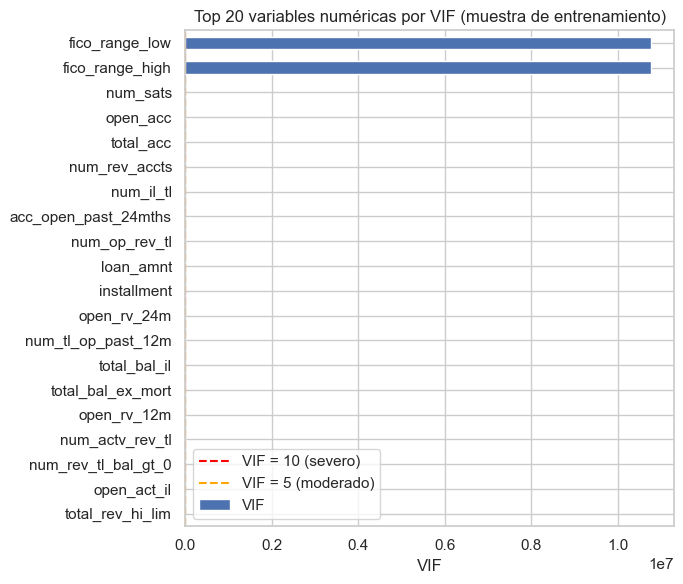

In [ ]:
if df_model is not None:
    get_ipython().run_line_magic('pip', 'install -q statsmodels')

    import statsmodels.api as sm
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from sklearn.impute import SimpleImputer

    N_MUESTRA_VIF = 50000

    X_train_num_muestra = X_train[VARS_NUMERICAS].sample(
        n=min(N_MUESTRA_VIF, len(X_train)), random_state=RANDOM_STATE
    )
    X_train_num_imputado = pd.DataFrame(
        SimpleImputer(strategy="median").fit_transform(X_train_num_muestra),
        columns=VARS_NUMERICAS,
    )
    X_train_vif = sm.add_constant(X_train_num_imputado)

    vif_valores = pd.Series(
        [variance_inflation_factor(X_train_vif.values, i)
         for i in range(1, X_train_vif.shape[1])],  # se salta la columna 0 (constante)
        index=VARS_NUMERICAS,
        name="VIF",
    ).sort_values(ascending=False)

    print(f"Variables con VIF > 10 (multicolinealidad severa): "
          f"{(vif_valores > 10).sum()} de {len(vif_valores)}")
    print(f"Variables con VIF > 5 (multicolinealidad moderada): "
          f"{(vif_valores > 5).sum()} de {len(vif_valores)}\n")

    display(vif_valores.head(20).round(2))

    vif_valores.head(20).sort_values().plot(kind="barh", figsize=(7, 6))
    plt.axvline(10, color="red", linestyle="--", label="VIF = 10 (severo)")
    plt.axvline(5, color="orange", linestyle="--", label="VIF = 5 (moderado)")
    plt.xlabel("VIF")
    plt.title("Top 20 variables numéricas por VIF (muestra de entrenamiento)")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("df_model no disponible todavía.")


### Anexo A.2 — `class_weight="balanced"` vs. Random Under-Sampling (RUS)

**Motivación:** RUS balancea el train set descartando muestras de la clase mayoritaria
al azar hasta igualar a la minoritaria -- de las ~369.940 filas de entrenamiento se
termina usando solo ~172.000 (se descarta más de la mitad de los "Pagados").
`class_weight="balanced"` logra el mismo objetivo (compensar el desbalance) pero
ponderando la función de pérdida, **sin descartar ninguna fila** -- usa el 100% del
set de entrenamiento.

Esto conecta directamente con la Sección 7.3: si la specificity sube al usar
`class_weight` en vez de RUS (manteniendo el resto de los hiperparámetros idénticos a
los de las Secciones 4.2/4.3), es evidencia de que **RUS mismo** -- no el modelo, no
las variables -- explica parte de la brecha de specificity frente al paper, al
descartar información real de la clase mayoritaria.

**Nota de cómputo:** a diferencia de la Sección 4.3, aquí Random Forest se entrena
sobre las 369.940 filas completas de `X_train` (sin submuestrear), lo que puede tardar
bastante más que esa celda -- son ~2,1x más filas y sin balancear.


--- Regresión logística + class_weight balanceado ---
  accuracy    : 0.6474
  precision   : 0.3626
  recall      : 0.6833
  specificity : 0.6365
  fp_rate     : 0.3635
  g_mean      : 0.6595
  f1          : 0.4738
  auc_roc     : 0.7200


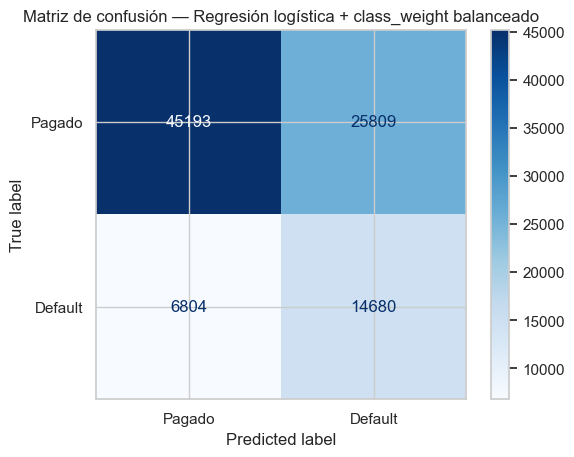

In [ ]:
if df_model is not None:
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import Pipeline

    pipeline_logreg_cw = Pipeline(steps=[
        ("preprocesador", preprocesador),
        ("clasificador", LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE,
        )),
    ])

    pipeline_logreg_cw.fit(X_train, y_train)

    metrica_logreg_cw = evaluar_modelo(
        "Regresión logística + class_weight balanceado",
        pipeline_logreg_cw, X_test, y_test, resultados, curvas_roc,
    )
else:
    print("df_model no disponible todavía.")


--- Random Forest + class_weight balanceado ---
  accuracy    : 0.7272
  precision   : 0.4219
  recall      : 0.4706
  specificity : 0.8049
  fp_rate     : 0.1951
  g_mean      : 0.6154
  f1          : 0.4449
  auc_roc     : 0.7184


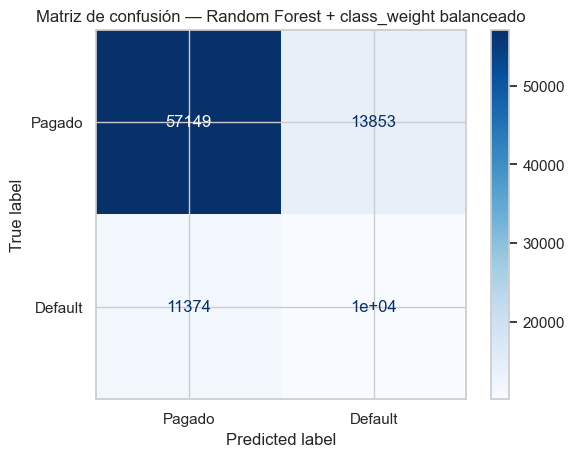

In [ ]:
if df_model is not None:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.pipeline import Pipeline

    # Mismos hiperparámetros que Random Forest + RUS (Sección 4.3), cambiando solo el
    # tratamiento del desbalance: class_weight en vez de RUS, sobre el 100% de X_train.
    pipeline_rf_cw = Pipeline(steps=[
        ("preprocesador", preprocesador),
        ("clasificador", RandomForestClassifier(
            n_estimators=250, max_depth=25, min_samples_leaf=2,
            class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
        )),
    ])

    pipeline_rf_cw.fit(X_train, y_train)

    metrica_rf_cw = evaluar_modelo(
        "Random Forest + class_weight balanceado",
        pipeline_rf_cw, X_test, y_test, resultados, curvas_roc,
    )
else:
    print("df_model no disponible todavía.")


In [ ]:
if df_model is not None:
    tabla_resultados_actual = pd.DataFrame(resultados).set_index("modelo")
    modelos_comparar_cw = [
        "Regresión logística + RUS",
        "Regresión logística + class_weight balanceado",
        "Random Forest + RUS",
        "Random Forest + class_weight balanceado",
    ]
    modelos_disponibles = [m for m in modelos_comparar_cw if m in tabla_resultados_actual.index]

    print("Comparación directa: RUS (descarta filas) vs. class_weight balanceado "
          "(usa el 100% de X_train):\n")
    display(tabla_resultados_actual.loc[
        modelos_disponibles, ["recall", "specificity", "g_mean", "auc_roc"]
    ].round(4))
else:
    print("df_model no disponible todavía.")


Comparación directa: RUS (descarta filas) vs. class_weight balanceado (usa el 100% de X_train):



,recall,specificity,g_mean,auc_roc
modelo,,,,
Regresión logística + RUS,0.6829,0.6364,0.6592,0.7199
Regresión logística + class_weight balanceado,0.6833,0.6365,0.6595,0.7200
Random Forest + RUS,0.6833,0.6306,0.6564,0.7183
Random Forest + class_weight balanceado,0.4706,0.8049,0.6154,0.7184


### Anexo A.3 — Interpretación de los resultados

**VIF (Anexo A.1):** 29 de 77 variables numéricas tienen VIF > 10 y 41 tienen VIF > 5 --
multicolinealidad extendida, esperable en variables de buró crediticio (muchas miden
versiones ligeramente distintas de "cuántas cuentas tiene el solicitante"). El caso más
extremo es `fico_range_low`/`fico_range_high` (VIF ≈ 10,76 millones): son, en la
práctica, la misma variable (el ancho de la banda FICO de LendingClub es casi
constante), así que su correlación casi perfecta es por construcción, no casualidad.
Esto **no invalida** los resultados de las Secciones 4-6: ni Random Forest ni XGBoost se
ven afectados por multicolinealidad, y la selección L1 (Sección 3.8) ya "resuelve" el
problema para la Regresión Logística al anular automáticamente los coeficientes
redundantes. Sí confirma que no conviene interpretar individualmente la *magnitud* de
los coeficientes de la Regresión Logística (ni del ranking L1) más allá del orden
relativo -- una salvedad útil si preguntan por el peso "causal" de una variable en la
exposición oral.

**`class_weight` vs. RUS (Anexo A.2) — resultado real:**

| Modelo | Recall | Specificity | G-Mean | AUC |
|---|---|---|---|---|
| LR + RUS | 0,683 | 0,636 | 0,659 | 0,720 |
| LR + class_weight | 0,683 | 0,637 | 0,660 | 0,720 |
| RF + RUS | 0,683 | 0,631 | 0,656 | 0,718 |
| RF + class_weight | **0,471** | **0,805** | 0,615 | 0,718 |

- **Para Regresión Logística, RUS y `class_weight` son prácticamente idénticos**
  (diferencias en la tercera decimal). Tiene sentido: para un modelo lineal, ponderar la
  log-verosimilitud por la frecuencia inversa de clase y submuestrear son,
  asintóticamente, formas equivalentes de desplazar el mismo límite de decisión. Esto
  descarta a RUS como explicación de cualquier brecha en LR frente al paper.
- **Para Random Forest, el resultado es dramáticamente distinto.** `class_weight` empuja
  a RF hacia mucha más specificity (0,805) y mucho menos recall (0,471) que RUS
  (specificity 0,631 / recall 0,683) -- de hecho, **supera** el 0,680 de specificity del
  paper, sobrecorrigiendo hacia el extremo opuesto. RUS y `class_weight` entregan
  resultados muy distintos para Random Forest, mucho más que para un modelo lineal, y el
  resultado del paper (recall 0,630 / specificity 0,680) queda casi exactamente **entre
  nuestros dos extremos** (RUS: 0,683/0,631; class_weight: 0,471/0,805). Esto sugiere que
  la brecha de specificity de RF frente al paper no depende solo de qué variables faltan,
  sino de **qué tan sensible es un Random Forest a la técnica específica de balanceo de
  clases** -- otra combinación (o una implementación de RUS distinta a la de los
  autores) podría aterrizar en cualquier punto de ese rango.
